# 1. Setup

## Environment

In [1]:
!nvidia-smi

Sat Jul 12 00:36:36 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P0             26W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!lscpu

Architecture:             x86_64
  CPU op-mode(s):         32-bit, 64-bit
  Address sizes:          46 bits physical, 48 bits virtual
  Byte Order:             Little Endian
CPU(s):                   4
  On-line CPU(s) list:    0-3
Vendor ID:                GenuineIntel
  Model name:             Intel(R) Xeon(R) CPU @ 2.00GHz
    CPU family:           6
    Model:                85
    Thread(s) per core:   2
    Core(s) per socket:   2
    Socket(s):            1
    Stepping:             3
    BogoMIPS:             4000.28
    Flags:                fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge m
                          ca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht sysc
                          all nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xt
                          opology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq
                           ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt
                           aes xsave avx f16c rdrand hypervisor 

In [3]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            31Gi       620Mi        23Gi       2.0Mi       7.0Gi        30Gi
Swap:             0B          0B          0B


In [4]:
!cat /etc/os-release

PRETTY_NAME="Ubuntu 22.04.4 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.4 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy


In [5]:
!df -h

Filesystem                                                              Size  Used Avail Use% Mounted on
overlay                                                                 7.9T  6.3T  1.7T  80% /
tmpfs                                                                    64M     0   64M   0% /dev
shm                                                                      14G     0   14G   0% /dev/shm
/dev/sda1                                                               122G  4.6G  118G   4% /opt/bin
/dev/loop1                                                               20G  332K   20G   1% /kaggle/lib
192.168.13.2:/data/kagglesdsdata/datasets/3570200/6216738/db7mbndydiq4   38T   26T   12T  69% /kaggle/input
/dev/mapper/snap                                                        7.9T  6.3T  1.7T  80% /etc/hosts
tmpfs                                                                    16G     0   16G   0% /proc/acpi
tmpfs                                                                 

## Libraries

In [6]:
# Instalação da biblioteca ultralytics
!pip install "ultralytics<=8.3.157" -q
!yolo settings sync=False tensorboard=True

# Importações de bibliotecas padrão
import os
import time
import shutil
import random
import requests
from glob import glob
import pandas as pd
from io import BytesIO
from collections import defaultdict

# Importações para manipulação de dados e visualização
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw, ImageFont

# Importação da biblioteca específica
import ultralytics
ultralytics.checks()
from ultralytics import YOLO
import albumentations as A
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score, roc_auc_score

# Optional: Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('ggplot')
%matplotlib inline

Ultralytics 8.3.157 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6411.4/8062.4 GB disk)


In [7]:
!pip freeze > requirements.txt

## Constants

In [8]:
ROOT_DIR = '/kaggle/working'
BASE_INPUT_PATH = '/kaggle/input'
BASE_OUTPUT_PATH = ROOT_DIR + '/tilda-kfold-splits'
PROJECT_NAME = 'yolo11m_cls_kfold_training'
YOLO_MODEL = 'yolo11m-cls.pt'

SAMPLE_IMAGE_URL = 'https://source.roboflow.com/FDdZOVfCZ6gwOEmxF8cdMHSxe8A2/hMohdfrWIeKDiTd2uZnB/original.jpg'
GOOD_FRACTION = 0.15 # keep 15% of 'good' patches for train
RANDOM_SEED = 42
NUM_FOLDS = 5
BATCH_SIZE = 64
NUM_EPOCHS = 200
HYP_SEARCH_SPACE = np.arange(0.0, 1.01, 0.01)

# --- DATASET SPLIT PARAMETERS ---
TRAIN_RATIO = 0.70
VAL_RATIO = 0.20
TEST_RATIO = 0.10

PATCH_SIZE = 64
FINAL_IMAGE_SIZE = 512 # 8x8 patches of 64px = 512px
EXPECTED_PATCHES_PER_IMAGE = (FINAL_IMAGE_SIZE // PATCH_SIZE)**2 # Should be 64 for 512x512
tau_1 = 0.95
tau_2 = 0.34

# Get class names from directories
CLASS_NAMES = sorted([d for d in os.listdir(BASE_INPUT_PATH) if os.path.isdir(os.path.join(BASE_INPUT_PATH, d))])
CLASS_COUNT = len(CLASS_NAMES)
CLASS_COLORS = {
    "good": (0, 255, 0),        # green
    "hole": (255, 0, 0),        # red
    "objects": (0, 0, 255),     # blue
    "oil spot": (255, 165, 0),  # orange
    "thread error": (128, 0, 128), # purple
}

print(f"Input dataset: {BASE_INPUT_PATH}")
print(f"Output directory for processed dataset: {BASE_OUTPUT_PATH}")
print(f"Classes found ({CLASS_COUNT}): {CLASS_NAMES}")

Input dataset: /kaggle/input
Output directory for processed dataset: /kaggle/working/tilda-kfold-splits
Classes found (5): ['good', 'hole', 'objects', 'oil spot', 'thread error']


## Seed

In [9]:
def set_seed(seed: int = 42) -> None:
    # Set a fixed value for the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Set seed for PyTorch
    torch.manual_seed(seed)
    # Set seed for CUDA (if using GPUs)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
    # Set seed for Python's random module
    random.seed(seed)
    # Set seed for NumPy
    np.random.seed(seed)
    #tf.random.set_seed(seed) # set random seed for TensorFlow
    print(f"Random seed set as {seed}")

set_seed(RANDOM_SEED)

Random seed set as 42


# 2. Dataset

## Visualization

Random seed set as 42
Total images found: 25600

Original image count per class:
good            23170
objects           837
oil spot          636
thread error      620
hole              337
dtype: int64


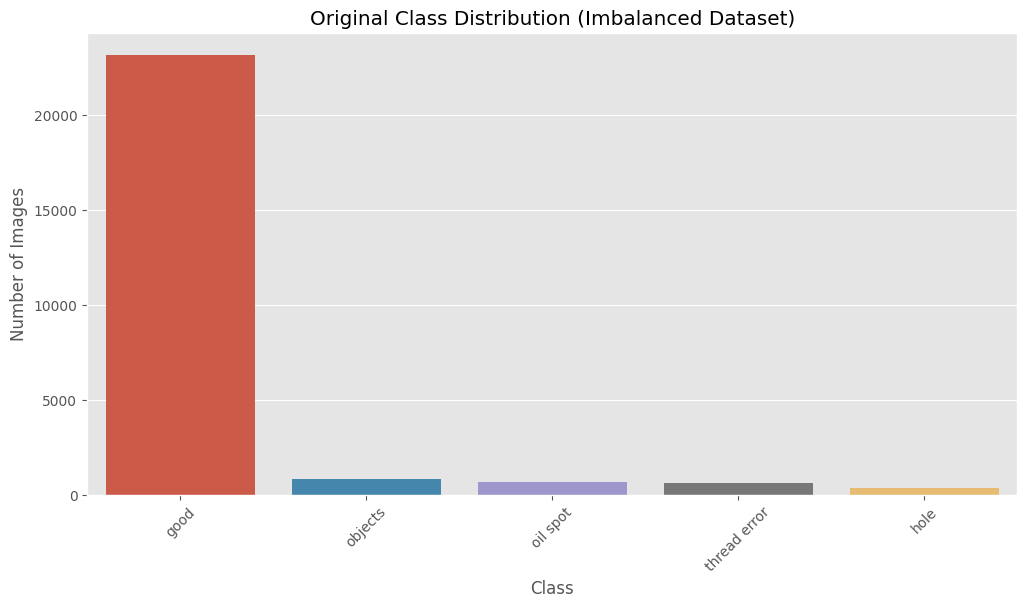

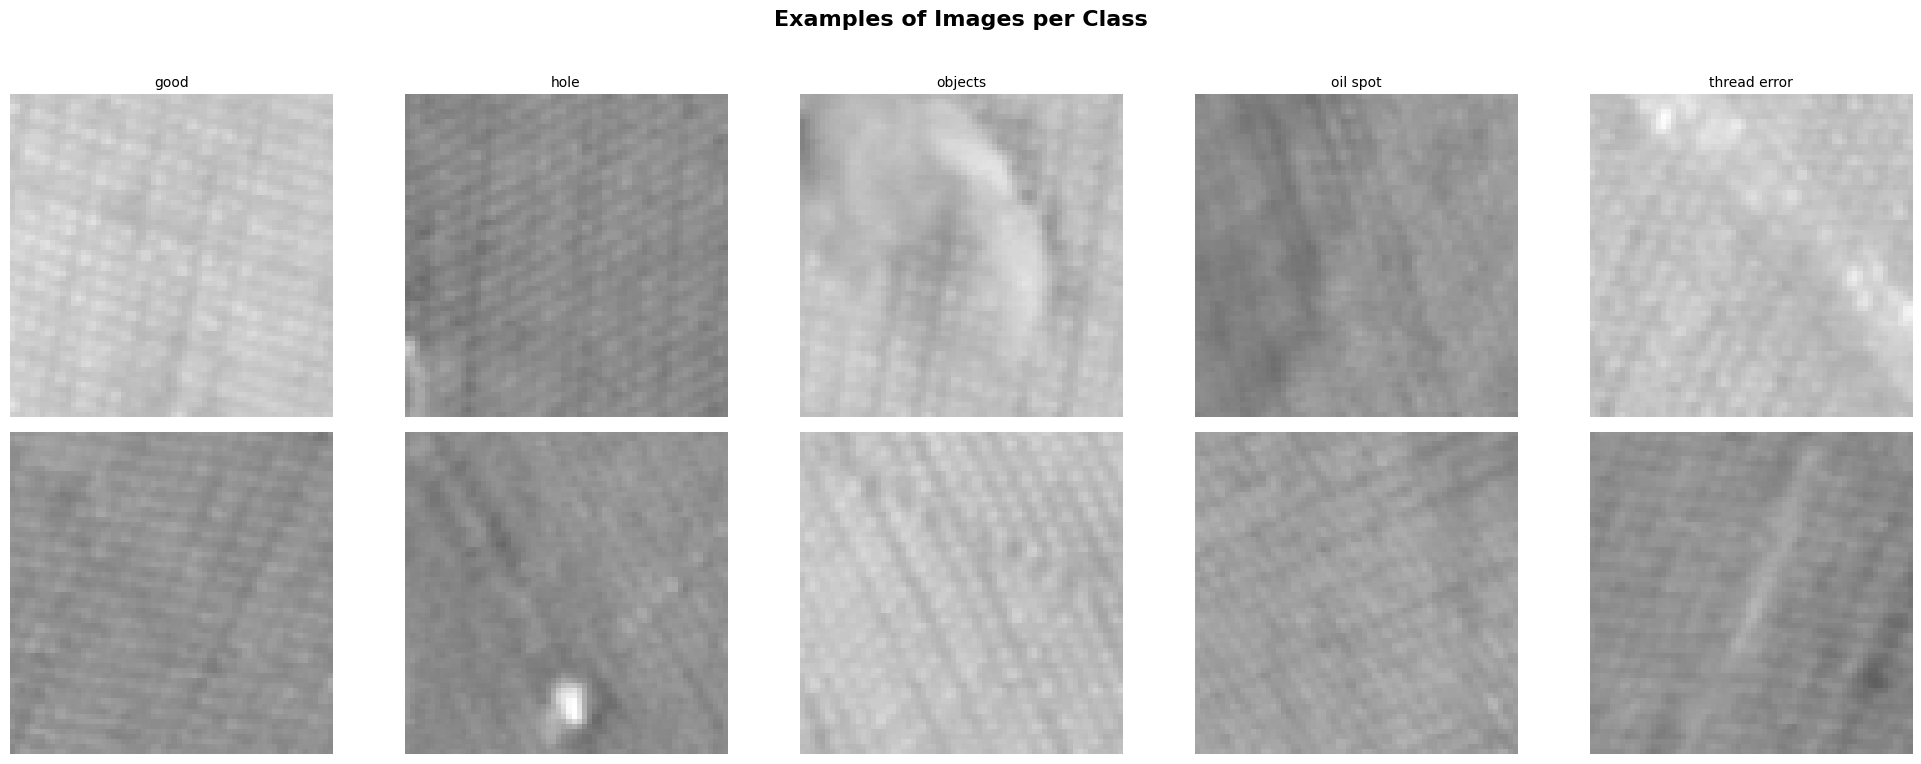

In [10]:
set_seed(RANDOM_SEED)

# Load all image paths and their respective labels
image_paths = []
labels = []
class_counts = {}

for class_name in CLASS_NAMES:
    class_dir = os.path.join(BASE_INPUT_PATH, class_name)
    paths = glob(os.path.join(class_dir, '*.png'))
    image_paths.extend(paths)
    labels.extend([class_name] * len(paths))
    class_counts[class_name] = len(paths)

# Create a DataFrame for facilitated visualization
df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels
})

print(f"Total images found: {len(df)}")
print("\nOriginal image count per class:")
print(pd.Series(class_counts).sort_values(ascending=False))

# Plot the original distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), order=pd.Series(class_counts).sort_values(ascending=False).index)
plt.title('Original Class Distribution (Imbalanced Dataset)')
plt.ylabel('Number of Images')
plt.xlabel('Class')
plt.xticks(rotation=45)
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=CLASS_COUNT, figsize=(CLASS_COUNT * 4, 8)) # Adjust figsize as needed
fig.suptitle('Examples of Images per Class', fontsize=16, weight='bold')

for i, class_name in enumerate(CLASS_NAMES):
    # Sample 2 image paths for the current class
    sample_paths = df[df['label'] == class_name]['image_path'].sample(2).values
    
    # Display the first image in the first row, 'i'-th column
    img1 = Image.open(sample_paths[0])
    axes[0, i].imshow(img1)
    axes[0, i].set_title(class_name, fontsize=10) # Set class name as title
    axes[0, i].axis('off')
    # Display the second image in the second row, 'i'-th column
    img2 = Image.open(sample_paths[1])
    axes[1, i].imshow(img2)
    axes[1, i].axis('off')

# Adjust layout to add padding between rows
plt.subplots_adjust(hspace=0.4)
plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust rect to ensure suptitle is visible
plt.show()

## Train/val/test splitting

Here we use Stratified KFold and undersampling techniques

In [11]:
set_seed(RANDOM_SEED)

# 1) Collect all unique image IDs AND their associated class types
# This is crucial for StratifiedKFold based on image IDs and their primary class.
# However, for patches, an image ID can have patches from multiple classes.
# The most robust way is to stratify based on the *patches* themselves,
# while ensuring patches from the same image ID stay together.

# Let's collect all patch paths along with their image_id and class_name
all_patch_data = [] # List of (patch_path, image_id, class_name) tuples
image_id_to_class_distribution = defaultdict(lambda: defaultdict(int))

for class_name in CLASS_NAMES:
    patch_paths = glob(os.path.join(BASE_INPUT_PATH, class_name, "*.png"))
    for path in patch_paths:
        fname = os.path.basename(path)
        image_id = fname.split("_patch")[0]
        all_patch_data.append((path, image_id, class_name))
        image_id_to_class_distribution[image_id][class_name] += 1

all_image_ids = sorted(list(image_id_to_class_distribution.keys()))
print(f"Found {len(all_image_ids)} unique image IDs and {len(all_patch_data)} total patches.")

# 2) Shuffle image IDs and split into a dedicated TEST set and a TRAINVAL pool
random.shuffle(all_image_ids)

num_total_images = len(all_image_ids)
num_test_images = max(1, int(num_total_images * TEST_RATIO))
test_image_ids = set(all_image_ids[:num_test_images])
trainval_pool_image_ids = set(all_image_ids[num_test_images:])

print(f"\nSplit {len(test_image_ids)} images for DEDICATED TEST set and {len(trainval_pool_image_ids)} for K-FOLD POOL.")

# Remove old outputs for k-fold
if os.path.exists(BASE_OUTPUT_PATH):
    shutil.rmtree(BASE_OUTPUT_PATH)
    print(f"\nRemoved previous K-Fold output directory '{BASE_OUTPUT_PATH}'.")

# Create and populate the dedicated test set directory
os.makedirs(os.path.join(BASE_OUTPUT_PATH, "test"), exist_ok=True)
for class_name in CLASS_NAMES:
    os.makedirs(os.path.join(BASE_OUTPUT_PATH, "test", class_name), exist_ok=True)

test_patch_count = 0
for patch_path, image_id, class_name in all_patch_data:
    if image_id in test_image_ids:
        dest_dir = os.path.join(BASE_OUTPUT_PATH, "test", class_name)
        shutil.copy(patch_path, dest_dir)
        test_patch_count += 1
print(f"Dedicated TEST set created with {test_patch_count} patches in '{BASE_OUTPUT_PATH}/test/'.")

image_id_labels_for_stratification = []
image_ids_in_pool = []

for image_id in trainval_pool_image_ids:
    has_defect = False
    for class_name, count in image_id_to_class_distribution[image_id].items():
        if class_name != 'good' and count > 0:
            has_defect = True
            break
    image_id_labels_for_stratification.append('defect' if has_defect else 'good')
    image_ids_in_pool.append(image_id) # Keep original order for KFold

print(f"\nApplying StratifiedKFold on {len(image_ids_in_pool)} image IDs in the trainval pool...")
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=RANDOM_SEED)

for fold_idx, (train_indices, val_indices) in enumerate(skf.split(image_ids_in_pool, image_id_labels_for_stratification)):
    print(f"\n--- Preparing Fold {fold_idx + 1}/{NUM_FOLDS} Data ---")

    current_train_image_ids = set(image_ids_in_pool[i] for i in train_indices)
    current_val_image_ids = set(image_ids_in_pool[i] for i in val_indices)

    # Initialize directories for the current fold
    fold_output_path = os.path.join(BASE_OUTPUT_PATH, f"fold_{fold_idx + 1}")
    train_fold_dir = os.path.join(fold_output_path, "train")
    val_fold_dir = os.path.join(fold_output_path, "val")

    # Clean up previous fold's directories if they exist (important if rerunning script)
    if os.path.exists(train_fold_dir):
        shutil.rmtree(train_fold_dir)
    if os.path.exists(val_fold_dir):
        shutil.rmtree(val_fold_dir)

    os.makedirs(train_fold_dir, exist_ok=True)
    os.makedirs(val_fold_dir, exist_ok=True)

    # Create class subdirectories within train/val
    for class_name in CLASS_NAMES:
        os.makedirs(os.path.join(train_fold_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_fold_dir, class_name), exist_ok=True)

    # Collect patches for the current train and val sets
    # Apply undersampling for 'good' class in the CURRENT TRAINING SET ONLY
    train_good_patches_for_undersampling = []
    val_patch_count = 0
    train_patch_count_before_undersample = 0

    # First, collect all potential patches for this fold's train/val
    # and identify 'good' patches in the train set for undersampling.
    patches_to_copy_train = defaultdict(list) # store (patch_path, dest_dir)
    patches_to_copy_val = defaultdict(list)

    for patch_path, image_id, class_name in all_patch_data:
        if image_id in current_train_image_ids:
            train_patch_count_before_undersample += 1
            if class_name == 'good':
                train_good_patches_for_undersampling.append(patch_path)
            else:
                patches_to_copy_train[class_name].append(patch_path)
        elif image_id in current_val_image_ids:
            val_patch_count += 1
            patches_to_copy_val[class_name].append(patch_path)

    # Undersample 'good' class patches in the current training set
    kept_good_train_patches = []
    if len(train_good_patches_for_undersampling) > 0:
        keep_count = max(1, int(len(train_good_patches_for_undersampling) * GOOD_FRACTION))
        kept_good_train_patches = random.sample(train_good_patches_for_undersampling, keep_count)
        print(f"  Undersampled 'good' in this fold's train set: {len(train_good_patches_for_undersampling)} → {len(kept_good_train_patches)} patches.")
    else:
        print("  No 'good' patches found in this fold's training set for undersampling.")

    # Now, copy the patches based on the determined sets
    current_train_patch_count = 0
    current_val_patch_count = 0

    # Copy undersampled 'good' patches to train
    for path in kept_good_train_patches:
        fname = os.path.basename(path)
        dest_dir = os.path.join(train_fold_dir, 'good')
        shutil.copy(path, dest_dir)
        current_train_patch_count += 1

    # Copy other classes to train
    for class_name, paths in patches_to_copy_train.items():
        if class_name != 'good': # Already handled 'good'
            for path in paths:
                fname = os.path.basename(path)
                dest_dir = os.path.join(train_fold_dir, class_name)
                shutil.copy(path, dest_dir)
                current_train_patch_count += 1

    # Copy validation patches
    for class_name, paths in patches_to_copy_val.items():
        for path in paths:
            fname = os.path.basename(path)
            dest_dir = os.path.join(val_fold_dir, class_name)
            shutil.copy(path, dest_dir)
            current_val_patch_count += 1


    print(f"  Fold {fold_idx + 1} data prepared: {current_train_patch_count} patches in '{train_fold_dir}', {current_val_patch_count} patches in '{val_fold_dir}'")
    print("-" * 50) # Separator for clarity

print("\n--- K-Fold Cross-Validation Dataset Splitting Complete ---")
print(f"Dataset split into {NUM_FOLDS} folds, plus a dedicated test set.")
print(f"Output structure: '{BASE_OUTPUT_PATH}/fold_X/train/' and '{BASE_OUTPUT_PATH}/fold_X/val/' for each fold.")
print(f"And '{BASE_OUTPUT_PATH}/test/' for the dedicated test set.")

Random seed set as 42
Found 400 unique image IDs and 25600 total patches.

Split 40 images for DEDICATED TEST set and 360 for K-FOLD POOL.
Dedicated TEST set created with 2560 patches in '/kaggle/working/tilda-kfold-splits/test/'.

Applying StratifiedKFold on 360 image IDs in the trainval pool...

--- Preparing Fold 1/5 Data ---
  Undersampled 'good' in this fold's train set: 16654 → 2498 patches.
  Fold 1 data prepared: 4276 patches in '/kaggle/working/tilda-kfold-splits/fold_1/train', 4608 patches in '/kaggle/working/tilda-kfold-splits/fold_1/val'
--------------------------------------------------

--- Preparing Fold 2/5 Data ---
  Undersampled 'good' in this fold's train set: 16633 → 2494 patches.
  Fold 2 data prepared: 4293 patches in '/kaggle/working/tilda-kfold-splits/fold_2/train', 4608 patches in '/kaggle/working/tilda-kfold-splits/fold_2/val'
--------------------------------------------------

--- Preparing Fold 3/5 Data ---
  Undersampled 'good' in this fold's train set: 166


Checking: /kaggle/working/tilda-kfold-splits/test
TEST     - good        : 2334 patches
TEST     - hole        : 40 patches
TEST     - objects     : 56 patches
TEST     - oil spot    : 91 patches
TEST     - thread error: 39 patches
FOLD_1  _TRAIN - good        : 2498 patches
FOLD_1  _TRAIN - hole        : 231 patches
FOLD_1  _TRAIN - objects     : 673 patches
FOLD_1  _TRAIN - oil spot    : 402 patches
FOLD_1  _TRAIN - thread error: 472 patches
FOLD_1  _VAL  - good        : 4182 patches
FOLD_1  _VAL  - hole        : 66 patches
FOLD_1  _VAL  - objects     : 108 patches
FOLD_1  _VAL  - oil spot    : 143 patches
FOLD_1  _VAL  - thread error: 109 patches
FOLD_2  _TRAIN - good        : 2494 patches
FOLD_2  _TRAIN - hole        : 254 patches
FOLD_2  _TRAIN - objects     : 615 patches
FOLD_2  _TRAIN - oil spot    : 447 patches
FOLD_2  _TRAIN - thread error: 483 patches
FOLD_2  _VAL  - good        : 4203 patches
FOLD_2  _VAL  - hole        : 43 patches
FOLD_2  _VAL  - objects     : 166 patches

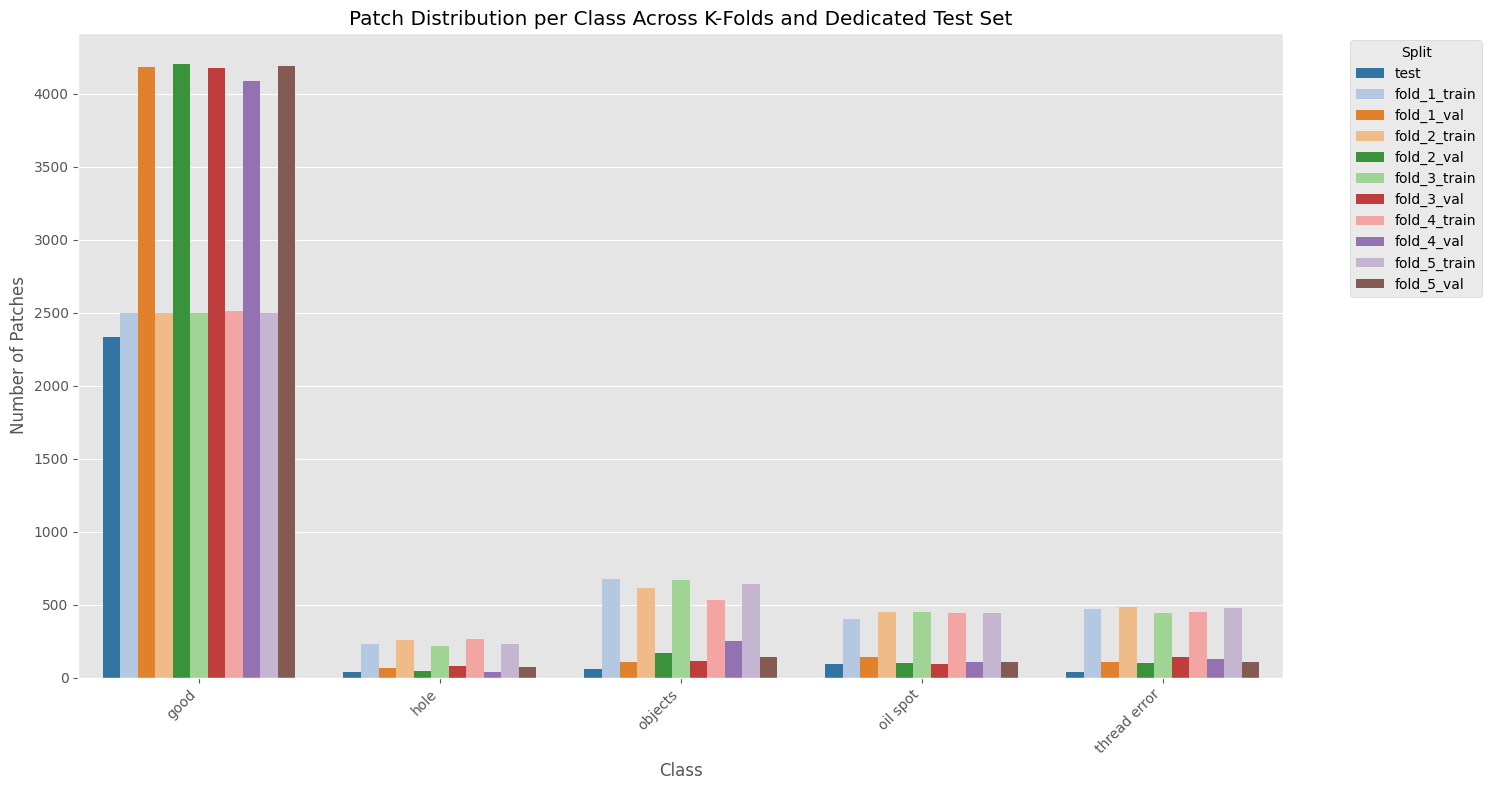


--- Averaged K-Fold Counts ---


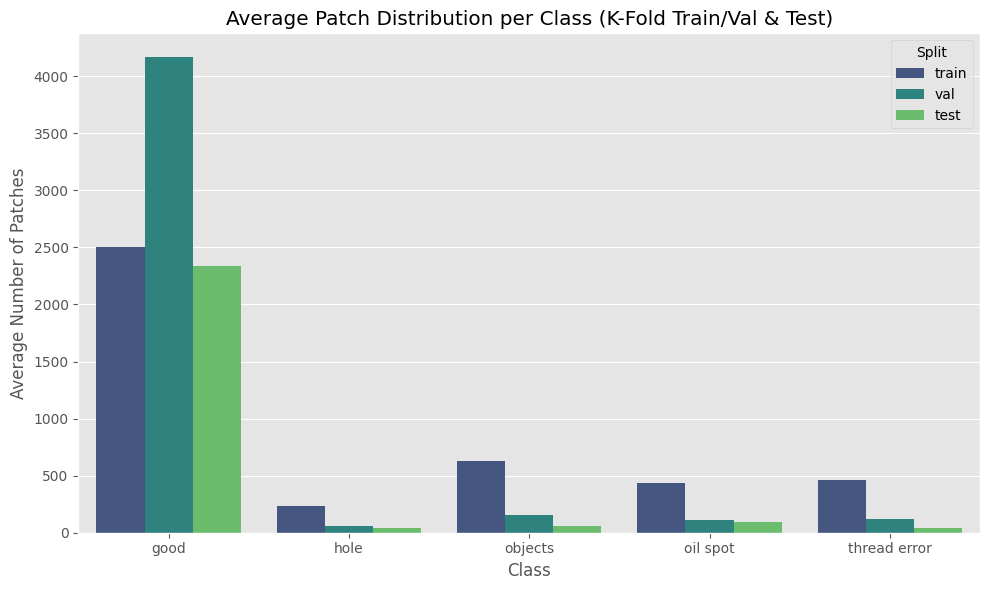


Visualization complete.


In [12]:
print("\nCollecting counts in each split...")

# Prepare a list to store all data points
all_split_counts_data = []

# 1. Collect counts for the dedicated TEST set (only once)
print(f"Checking: {os.path.join(BASE_OUTPUT_PATH, 'test')}")
if os.path.exists(os.path.join(BASE_OUTPUT_PATH, 'test')):
    for class_name in CLASS_NAMES:
        files = glob(os.path.join(BASE_OUTPUT_PATH, "test", class_name, '*.png'))
        count = len(files)
        all_split_counts_data.append({'split': 'test', 'class': class_name, 'count': count})
        print(f"{'TEST':8} - {class_name:12}: {count} patches")
else:
    print(f"Warning: Dedicated TEST set directory not found at {os.path.join(BASE_OUTPUT_PATH, 'test')}")

# 2. Collect counts for each K-Fold's train and val sets
for fold_idx in range(NUM_FOLDS):
    fold_name = f"fold_{fold_idx + 1}"
    fold_base_path = os.path.join(BASE_OUTPUT_PATH, fold_name)

    if os.path.exists(fold_base_path):
        for split_type in ['train', 'val']:
            for class_name in CLASS_NAMES:
                files = glob(os.path.join(fold_base_path, split_type, class_name, '*.png'))
                count = len(files)
                # We'll use a combined name like 'fold_1_train' for the plot
                all_split_counts_data.append({'split': f"{fold_name}_{split_type}", 'class': class_name, 'count': count})
                print(f"{fold_name.upper():8}_{split_type.upper():4} - {class_name:12}: {count} patches")
    else:
        print(f"Warning: Fold directory '{fold_base_path}' not found. Skipping.")

# Convert to DataFrame
df_counts = pd.DataFrame(all_split_counts_data)

# --- Visualization ---

# Plotting each fold's train/val and the test set
plt.figure(figsize=(15, 8))
sns.barplot(data=df_counts, x='class', y='count', hue='split', palette='tab20')
plt.title('Patch Distribution per Class Across K-Folds and Dedicated Test Set')
plt.ylabel('Number of Patches')
plt.xlabel('Class')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Split', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Averaging counts for 'train' and 'val' across folds for a cleaner summary
# This is more useful for a high-level overview of the k-fold balance.
print("\n--- Averaged K-Fold Counts ---")
# Filter for train/val splits within folds
df_train_val_folds = df_counts[df_counts['split'].str.contains('fold_')].copy()

# Extract 'train' or 'val' type
df_train_val_folds['split_type'] = df_train_val_folds['split'].apply(lambda x: x.split('_')[-1])

# Calculate average counts for train and val across folds
avg_fold_counts = df_train_val_folds.groupby(['split_type', 'class'])['count'].mean().reset_index()
avg_fold_counts['split'] = avg_fold_counts['split_type'] # Rename column for merging

# Add the dedicated test set back
df_test_only = df_counts[df_counts['split'] == 'test'].copy()
df_test_only['split_type'] = 'test' # Assign 'test' to split_type

# Combine for final averaged plot
combined_avg_df = pd.concat([avg_fold_counts, df_test_only[['split_type', 'class', 'count', 'split']]])

plt.figure(figsize=(10, 6))
sns.barplot(data=combined_avg_df, x='class', y='count', hue='split', palette='viridis')
plt.title('Average Patch Distribution per Class (K-Fold Train/Val & Test)')
plt.ylabel('Average Number of Patches')
plt.xlabel('Class')
plt.legend(title='Split')
plt.tight_layout()
plt.show()

print("\nVisualization complete.")

In [13]:
def verify_split_completeness(split_path, class_names, expected_patches_per_image=64, is_train_split=False):
    """
    Verifies patch completeness for images within a given split directory.

    Args:
        split_path (str): The path to the split directory (e.g., 'path/to/test', 'path/to/fold_1/train').
        class_names (list): A list of class names.
        expected_patches_per_image (int): The expected number of patches for each original image ID
                                          if no undersampling occurs (e.g., 64).
        is_train_split (bool): True if this is a training split (where 'good' class is undersampled).
                               This affects the interpretation of 'completeness'.

    Returns:
        tuple: A tuple containing:
            - dict: A dictionary where keys are original image IDs found,
                    and values are the count of patches found for that image ID.
            - bool: True if all image IDs have the expected_patches_per_image (for non-train splits).
                    For train splits, it returns True if all image IDs found have at least 1 patch.
    """
    if not os.path.exists(split_path):
        print(f"Error: Split directory not found at '{split_path}'. Skipping verification.")
        return {}, False

    image_id_patch_counts = defaultdict(int)
    all_image_ids_in_split = set()

    # Iterate through each class subdirectory
    for class_name in class_names:
        class_dir = os.path.join(split_path, class_name)
        if os.path.exists(class_dir):
            patch_files = glob(os.path.join(class_dir, "*.png"))
            for patch_path in patch_files:
                fname = os.path.basename(patch_path)
                image_id = fname.split("_patch")[0]
                image_id_patch_counts[image_id] += 1
                all_image_ids_in_split.add(image_id)

    all_images_complete = True
    if not all_image_ids_in_split:
        all_images_complete = False # No images found in this split

    for image_id in sorted(list(all_image_ids_in_split)):
        count = image_id_patch_counts[image_id]
        if is_train_split:
            # For train, we expect less than 64 for images with 'good' patches
            # We just confirm they have some patches (at least 1)
            # A more rigorous check would require knowing the exact undersampled patch list.
            if count == 0: # Should not happen if image_id is in all_image_ids_in_split
                all_images_complete = False
        else: # For val and test, we expect exactly 64
            if count != expected_patches_per_image:
                all_images_complete = False

    return image_id_patch_counts, all_images_complete

# --- Main verification execution ---

print("\n--- Verifying Patch Completeness Across All Splits ---")

# 1. Verify the Dedicated TEST set
test_dir = os.path.join(BASE_OUTPUT_PATH, "test")
test_image_counts, test_is_complete = verify_split_completeness(test_dir, CLASS_NAMES, is_train_split=False)
print(f"\nVerification for TEST set ('{test_dir}'):")
print(f"  Image IDs found: {len(test_image_counts)}")
# for img_id, count in sorted(test_image_counts.items()):
#     status = "COMPLETE" if count == 64 else f"INCOMPLETE ({count}/64)"
#     print(f"    - {img_id}: {count} patches ({status})")
if test_is_complete:
    print("  Summary: ✅ All images in TEST set are complete (64 patches/image ID).")
else:
    print("  Summary: ❌ Some images in TEST set are incomplete.")


# 2. Verify TRAIN and VAL sets for each K-Fold
for fold_idx in range(NUM_FOLDS):
    fold_name = f"fold_{fold_idx + 1}"
    fold_base_path = os.path.join(BASE_OUTPUT_PATH, fold_name)

    # Verify TRAIN split of current fold
    train_fold_dir = os.path.join(fold_base_path, "train")
    train_image_counts, train_is_complete = verify_split_completeness(train_fold_dir, CLASS_NAMES, is_train_split=True)
    print(f"\nVerification for {fold_name.upper()}_TRAIN ('{train_fold_dir}'):")
    print(f"  Image IDs found: {len(train_image_counts)}")
    if train_is_complete: # This check is now simplified for train: just verifies presence
        print(f"  Summary: ✅ All images in {fold_name.upper()}_TRAIN set have expected patches (considering undersampling).")
    else:
        print(f"  Summary: ❌ Some images in {fold_name.upper()}_TRAIN set are incomplete or missing.")


    # Verify VAL split of current fold
    val_fold_dir = os.path.join(fold_base_path, "val")
    val_image_counts, val_is_complete = verify_split_completeness(val_fold_dir, CLASS_NAMES, is_train_split=False)
    print(f"\nVerification for {fold_name.upper()}_VAL ('{val_fold_dir}'):")
    print(f"  Image IDs found: {len(val_image_counts)}")
    if val_is_complete:
        print(f"  Summary: ✅ All images in {fold_name.upper()}_VAL set are complete (64 patches/image ID).")
    else:
        print(f"  Summary: ❌ Some images in {fold_name.upper()}_VAL set are incomplete.")

print("\n--- All Split Verifications Complete ---")


--- Verifying Patch Completeness Across All Splits ---

Verification for TEST set ('/kaggle/working/tilda-kfold-splits/test'):
  Image IDs found: 40
  Summary: ✅ All images in TEST set are complete (64 patches/image ID).

Verification for FOLD_1_TRAIN ('/kaggle/working/tilda-kfold-splits/fold_1/train'):
  Image IDs found: 288
  Summary: ✅ All images in FOLD_1_TRAIN set have expected patches (considering undersampling).

Verification for FOLD_1_VAL ('/kaggle/working/tilda-kfold-splits/fold_1/val'):
  Image IDs found: 72
  Summary: ✅ All images in FOLD_1_VAL set are complete (64 patches/image ID).

Verification for FOLD_2_TRAIN ('/kaggle/working/tilda-kfold-splits/fold_2/train'):
  Image IDs found: 288
  Summary: ✅ All images in FOLD_2_TRAIN set have expected patches (considering undersampling).

Verification for FOLD_2_VAL ('/kaggle/working/tilda-kfold-splits/fold_2/val'):
  Image IDs found: 72
  Summary: ✅ All images in FOLD_2_VAL set are complete (64 patches/image ID).

Verification 

In [14]:
source_test_folder = os.path.join(BASE_OUTPUT_PATH, "test")

if not os.path.exists(source_test_folder):
    print(f"Error: Source test folder not found at '{source_test_folder}'. Cannot copy.")
else:
    print(f"\n--- Copying contents of '{source_test_folder}' into each fold's directory ---")
    
    for fold_idx in range(NUM_FOLDS):
        target_fold_path = os.path.join(BASE_OUTPUT_PATH, f"fold_{fold_idx + 1}")
        target_test_folder_in_fold = os.path.join(target_fold_path, "test")

        if not os.path.exists(target_fold_path):
            print(f"Warning: Fold directory '{target_fold_path}' not found. Skipping copy for this fold.")
            continue

        # Remove existing target test folder in fold if it exists, to ensure a clean copy
        if os.path.exists(target_test_folder_in_fold):
            print(f"  Removing existing '{target_test_folder_in_fold}'...")
            shutil.rmtree(target_test_folder_in_fold)

        # Copy the entire directory structure and its contents
        print(f"  Copying '{source_test_folder}' to '{target_test_folder_in_fold}'...")
        shutil.copytree(source_test_folder, target_test_folder_in_fold)
        print(f"  Successfully copied test data into '{target_fold_path}'.")

    print("\n--- Copying process complete ---")


--- Copying contents of '/kaggle/working/tilda-kfold-splits/test' into each fold's directory ---
  Copying '/kaggle/working/tilda-kfold-splits/test' to '/kaggle/working/tilda-kfold-splits/fold_1/test'...
  Successfully copied test data into '/kaggle/working/tilda-kfold-splits/fold_1'.
  Copying '/kaggle/working/tilda-kfold-splits/test' to '/kaggle/working/tilda-kfold-splits/fold_2/test'...
  Successfully copied test data into '/kaggle/working/tilda-kfold-splits/fold_2'.
  Copying '/kaggle/working/tilda-kfold-splits/test' to '/kaggle/working/tilda-kfold-splits/fold_3/test'...
  Successfully copied test data into '/kaggle/working/tilda-kfold-splits/fold_3'.
  Copying '/kaggle/working/tilda-kfold-splits/test' to '/kaggle/working/tilda-kfold-splits/fold_4/test'...
  Successfully copied test data into '/kaggle/working/tilda-kfold-splits/fold_4'.
  Copying '/kaggle/working/tilda-kfold-splits/test' to '/kaggle/working/tilda-kfold-splits/fold_5/test'...
  Successfully copied test data into '/

In [15]:
# Helper method
def delete_folder(path):
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f"Folder '{path}' and its contents deleted successfully.")
    else:
        print(f"Folder '{path}' does not exist.")

delete_folder("/kaggle/working/runs")

Folder '/kaggle/working/runs' does not exist.


# 3. Training

## Train model

In [16]:
set_seed(RANDOM_SEED)

all_fold_training_times_seconds = []

print("--- Starting K-Fold Cross-Validation Training ---")

for fold_idx in range(NUM_FOLDS):
    current_fold_name = f"fold_{fold_idx + 1}"
    fold_data_path = os.path.join(BASE_OUTPUT_PATH, current_fold_name)
    
    # Check if the data directory for the current fold exists.
    if not os.path.isdir(fold_data_path):
        print(f"Warning: Data directory not found for Fold {fold_idx + 1} at '{fold_data_path}'. Skipping.")
        continue

    print(f"\n--- Training Model ({YOLO_MODEL}) for Fold {fold_idx + 1}/{NUM_FOLDS} ---")

    # Load a fresh, pre-trained YOLO classification model for each fold.
    model = YOLO(YOLO_MODEL)

    # --- Start time tracking for the current fold ---
    start_time = time.time()

    # Execute the training process.
    # The 'project' and 'name' arguments dictate the save location of the results and model weights.
    model.train(
        data=fold_data_path,             # Path to the current fold's 'train' and 'val' subdirectories.
        epochs=NUM_EPOCHS,               # Adjust as needed.
        imgsz=PATCH_SIZE,                # Image size.
        batch=BATCH_SIZE,                # Batch size; adjust based on VRAM.
        project=PROJECT_NAME,            # Groups all fold runs into a single project directory.
        name=f'tilda_patches_{current_fold_name}', # Creates a unique run name for this fold.
        seed=RANDOM_SEED,
        # Data Augmentation Parameters
        degrees=20, 
        translate=0.1, 
        scale=0.1, 
        flipud=0.5, 
        fliplr=0.5, 
        hsv_h=0.015, 
        hsv_s=0.7, 
        hsv_v=0.4
    )

    # --- End time tracking for the current fold ---
    end_time = time.time()
    fold_training_duration = end_time - start_time
    all_fold_training_times_seconds.append(fold_training_duration)
    print(f"Fold {fold_idx + 1} Training Time: {fold_training_duration:.2f} seconds.")


print("\n--- All Folds Trained Successfully ---")
print(f"Trained model weights are saved under the '{PROJECT_NAME}' directory.")

### Training Time Summary ###
print("\n" + "="*60)
print("--- K-Fold Cross-Validation Training Time Summary ---")
print("="*60)

if all_fold_training_times_seconds:
    mean_training_time = np.mean(all_fold_training_times_seconds)
    std_dev_training_time = np.std(all_fold_training_times_seconds)
    
    print(f"✅ Mean Training Time per fold across {len(all_fold_training_times_seconds)} folds: {mean_training_time:.2f}s")
    print(f"   Standard Deviation of Training Time: {std_dev_training_time:.2f} seconds")
else:
    print("❌ No training times were recorded for any fold. This might indicate an issue with data directories or training process.")

Random seed set as 42
--- Starting K-Fold Cross-Validation Training ---

--- Training Model (yolo11m-cls.pt) for Fold 1/5 ---


100%|██████████| 22.4M/22.4M [00:01<00:00, 14.5MB/s]


New https://pypi.org/project/ultralytics/8.3.165 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.157 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/tilda-kfold-splits/fold_1, degrees=20, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=tilda_patches_fold_1, n

E0000 00:00:1752280957.061353      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752280957.117250      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Overriding model.yaml nc=80 with nc=5

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  1   1380352  ultralytics.nn.modules.block.C3k2            [512, 512, 1, True]           
  7                  -1  1   2360320  ultralytics

...

    200/200      1.45G     0.2627         56         64: 100%|██████████| 67/67 [00:05<00:00, 11.18it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 36/36 [00:01<00:00, 22.86it/s]

                   all      0.955          1



200 epochs completed in 0.380 hours.
Optimizer stripped from yolo11m_cls_kfold_training/tilda_patches_fold_5/weights/last.pt, 20.9MB
Optimizer stripped from yolo11m_cls_kfold_training/tilda_patches_fold_5/weights/best.pt, 20.9MB

Validating yolo11m_cls_kfold_training/tilda_patches_fold_5/weights/best.pt...
Ultralytics 8.3.157 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11m-cls summary (fused): 57 layers, 10,348,037 parameters, 0 gradients, 39.3 GFLOPs
train: /kaggle/working/tilda-kfold-splits/fold_5/train... found 4280 images in 5 classes ✅ 
val: /kaggle/working/tilda-kfold-splits/fold_5/val... found 4608 images in 5 classes ✅ 
test: /kaggle/working/tilda-kfold-splits/fold_5/test... found 2560 images in 5 classes ✅ 


               classes   top1_acc   top5_acc: 100%|██████████| 36/36 [00:01<00:00, 23.56it/s]


                   all      0.962          1
Speed: 0.0ms preprocess, 0.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to yolo11m_cls_kfold_training/tilda_patches_fold_5
Fold 5 Training Time: 1375.57 seconds.

--- All Folds Trained Successfully ---
Trained model weights are saved under the 'yolo11m_cls_kfold_training' directory.

--- K-Fold Cross-Validation Training Time Summary ---
✅ Mean Training Time per fold across 5 folds: 1356.60s
   Standard Deviation of Training Time: 14.18 seconds


## Save training artifacts

In [17]:
source_dir = os.path.join(ROOT_DIR, PROJECT_NAME)
output_zip_name = os.path.join(ROOT_DIR, f"{PROJECT_NAME}_archive")

print(f"--- Attempting to zip '{source_dir}' ---")

if os.path.exists(source_dir):
    try:
        # Create a zip archive
        shutil.make_archive(output_zip_name, 'zip', root_dir=ROOT_DIR, base_dir=PROJECT_NAME)
        print(f"Successfully created zip file: '{output_zip_name}.zip'")
        print("You can now download this file from your Kaggle output directory.")
    except Exception as e:
        print(f"An error occurred during zipping: {e}")
else:
    print(f"Error: Source directory '{source_dir}' not found. Cannot create zip file.")

--- Attempting to zip '/kaggle/working/yolo11m_cls_kfold_training' ---
Successfully created zip file: '/kaggle/working/yolo11m_cls_kfold_training_archive.zip'
You can now download this file from your Kaggle output directory.


# 4. Evaluation

## Helper functions

In [18]:
def plot_confusion_matrix(cm, class_names, title, ax=None, cmap="Blues", normalize=True):
    """
    Plots a confusion matrix using seaborn.

    Args:
        cm (np.ndarray): The confusion matrix (raw counts). Expected format:
                         Rows correspond to True Labels, Columns correspond to Predicted Labels.
                         (This is the standard output format of sklearn.metrics.confusion_matrix)
        class_names (list): List of class names.
        title (str): Title of the plot.
        ax (matplotlib.axes.Axes, optional): Axes to plot on. If None, a new figure and axes are created.
        cmap (str, optional): Colormap for the heatmap. Defaults to "Blues".
        normalize (bool, optional): If True, normalizes the confusion matrix rows to sum to 1.0.
                                    Defaults to True.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 7))

    # --- Normalization Logic ---
    if normalize:
        # Sum of each row (true labels)
        row_sums = cm.sum(axis=1, keepdims=True)
        # Avoid division by zero for classes with no true instances
        # Removed * 100 to display as proportions (0.00-1.00)
        normalized_cm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
        plot_data = normalized_cm
        fmt = ".2f"  # Format for two decimal places (e.g., 0.93)
        display_title = title
    else:
        plot_data = cm
        fmt = "d"  # Format for integers (raw counts)
        display_title = title

    sns.heatmap(plot_data, annot=True, fmt=fmt, cmap=cmap, cbar=True, ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=.5, linecolor='lightgray')
    
    ax.set_title(display_title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12) # X-axis corresponds to columns of the matrix
    ax.set_ylabel('True Label', fontsize=12)     # Y-axis corresponds to rows of the matrix
    
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

print("`plot_confusion_matrix` function defined.")

`plot_confusion_matrix` function defined.


In [19]:
def plot_f1_comparison(f1_raw, f1_tau12, class_names, title="F1-Score Comparison per Class"):
    """
    Plots a grouped bar chart comparing F1-scores for each class between two approaches.
    Includes an 'All Classes' category showing the mean F1-score.

    Args:
        f1_raw (np.ndarray): F1-scores for the raw inference approach.
        f1_tau12 (np.ndarray): F1-scores for the tau_1 + tau_2 adjusted approach.
        class_names (list): List of class names.
        title (str, optional): Title of the plot. Defaults to "F1-Score Comparison per Class".
    """
    if len(f1_raw) != len(f1_tau12) or len(f1_raw) != len(class_names):
        print("Error: F1-score arrays or class_names length mismatch for comparison plot.")
        return

    # Calculate mean F1-scores for 'All Classes'
    mean_f1_raw = np.mean(f1_raw)
    mean_f1_tau12 = np.mean(f1_tau12)

    # Prepare data for DataFrame
    # Start with individual class data
    data = {
        'Class': class_names * 2,
        'F1-Score': np.concatenate((f1_raw, f1_tau12)),
        'Approach': ['Raw Inference'] * len(class_names) + ['Flood Fill'] * len(class_names)
    }
    df = pd.DataFrame(data)

    # Append 'All Classes' data
    all_classes_data = pd.DataFrame({
        'Class': ['All Classes', 'All Classes'],
        'F1-Score': [mean_f1_raw, mean_f1_tau12],
        'Approach': ['Raw Inference', 'Flood Fill']
    })
    df = pd.concat([df, all_classes_data], ignore_index=True)

    plt.figure(figsize=(12, 7)) # Increased figure width to accommodate 'All Classes' bar
    sns.barplot(x='Class', y='F1-Score', hue='Approach', data=df, palette='deep')
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('F1-Score', fontsize=12)
    plt.xlabel('Class', fontsize=12)
    plt.ylim(0, 1.05) # F1-score ranges from 0 to 1
    
    # Rotate x-axis labels for readability, especially with 'All Classes'
    plt.xticks(rotation=45, ha='right') 
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

print("`plot_f1_comparison` function defined.")

`plot_f1_comparison` function defined.


In [20]:
def evaluate_patch_predictions(gt_labels, pred_labels, pred_probs, class_names, verbose=True, plot_cm=False, approach_name=""):
    """
    Calculates and prints quantitative metrics (confusion matrix, accuracy, precision, recall, F1, AUC)
    at the patch level. Optionally plots confusion matrix and F1-scores.

    Args:
        gt_labels (list): List of ground truth string labels for all patches.
        pred_labels (list): List of predicted string labels for all patches (hard labels).
        pred_probs (np.ndarray): NumPy array of predicted probabilities for each class for all patches.
                                 Shape: (num_patches, num_classes).
        class_names (list): List of all possible class names (strings), in a fixed order.
        verbose (bool, optional): If True, prints detailed metrics. Defaults to True.
        plot_cm (bool, optional): If True, plots the confusion matrix. Defaults to False.
        approach_name (str, optional): Name of the current approach (e.g., "Raw", "Tau-adjusted") for plots.
                                       Defaults to "".

    Returns:
        dict: A dictionary containing the calculated metrics.
    """
    if len(gt_labels) == 0 or len(pred_labels) == 0:
        if verbose:
            print("No labels to evaluate for quantitative metrics.")
        return {}

    if verbose:
        print(f"\n--- Evaluating {len(gt_labels)} Patch Predictions ({approach_name}) ---")

    # Convert string labels to integer indices for scikit-learn
    name_to_idx = {name: i for i, name in enumerate(class_names)}
    gt_indices = [name_to_idx[gt] for gt in gt_labels]
    pred_indices = [name_to_idx[pred] for pred in pred_labels]

    # Build confusion matrix
    cm = confusion_matrix(gt_indices, pred_indices, labels=range(len(class_names)))

    if verbose:
        print("\nConfusion matrix (rows: Ground Truth, columns: Predicted):")
        max_name_len = max(len(name) for name in class_names)
        col_width = max(8, max_name_len + 1)
        
        # Print header
        print(f"{'':<{max_name_len+2}}" + "".join(f"{name:<{col_width}}" for name in class_names))
        # Print rows
        for i, row in enumerate(cm):
            print(f"{class_names[i]:<{max_name_len+1}}: " + "".join(f"{v:<{col_width}}" for v in row))

    # Overall accuracy
    acc = accuracy_score(gt_indices, pred_indices)

    # Per-class precision, recall, f1
    precision, recall, f1, _ = precision_recall_fscore_support(
        gt_indices, pred_indices, labels=range(len(class_names)), zero_division=0
    )

    if verbose:
        print(f"\nOverall patch-level accuracy: {acc:.3f}\n")
        print("Class-specific patch-level metrics:")
        print(f"{'Class':<{max_name_len+1}} {'Prec':>6} {'Rec':>6} {'F1':>6}")
        
    for i, cname in enumerate(class_names):
        if verbose:
            print(f"{cname:<{max_name_len+1}} {precision[i]:6.3f} {recall[i]:6.3f} {f1[i]:6.3f}")

    # Calculate and print mean precision, recall, F1
    mean_precision = np.mean(precision)
    mean_recall = np.mean(recall)
    mean_f1 = np.mean(f1)
    if verbose:
        print(f"{'all classes':<{max_name_len+1}} {mean_precision:6.3f} {mean_recall:6.3f} {mean_f1:6.3f}")

    # Calculate and print AUC score
    roc_auc = 0.0
    if pred_probs is not None and len(pred_probs) > 0:
        # Ensure pred_probs has the correct shape for multi_class 'ovr'
        if pred_probs.ndim == 1: # If it's binary classification and pred_probs is 1D
            if len(class_names) == 2: # Binary case: need probabilities for positive class
                roc_auc = roc_auc_score(gt_indices, pred_probs, average='weighted', labels=range(len(class_names)))
            else: # Multi-class but 1D pred_probs - this is an error
                if verbose:
                    print("\nWarning: Multi-class problem but pred_probs is 1D. Skipping ROC AUC calculation.")
        elif pred_probs.ndim == 2 and pred_probs.shape[1] == len(class_names):
            roc_auc = roc_auc_score(gt_indices, pred_probs, multi_class='ovr', average='weighted', labels=range(len(class_names)))
        else:
            if verbose:
                print("\nWarning: pred_probs shape mismatch for ROC AUC calculation. Skipping.")
    else:
        if verbose:
            print("\nPredicted probabilities (y_score) not provided or empty, skipping ROC AUC calculation.")

    # --- Plotting Confusion Matrix ---
    if plot_cm:
        plot_confusion_matrix(cm, class_names, f'Confusion Matrix: {approach_name} Predictions')
        plt.show() # Show the plot immediately after creation

    metrics_dict = {
        "confusion_matrix": cm,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mean_precision": mean_precision,
        "mean_recall": mean_recall,
        "mean_f1": mean_f1,
        "roc_auc": roc_auc
    }
    return metrics_dict

print("`evaluate_patch_predictions` function defined with plotting capabilities.")

`evaluate_patch_predictions` function defined with plotting capabilities.


In [21]:
def scan_test_folder_completeness(base_output_path, class_names, expected_patches):
    """
    Scans the test folder to count unique images and identify complete ones
    (those with the expected number of patches).

    Args:
        base_output_path (str): The base directory containing the 'test' folder.
        class_names (list): A list of class subdirectory names within 'test'.
        expected_patches (int): The number of patches expected for a complete image.

    Returns:
        dict: A dictionary mapping image_id to a list of (patch_path, x, y, true_class_name) tuples.
              Also prints summary statistics.
    """
    test_dir = os.path.join(base_output_path, "test")

    if not os.path.exists(test_dir):
        print(f"Error: Test directory not found at '{test_dir}'. Please ensure your data splitting created it.")
        return {}

    print(f"\n--- Scanning Test Folder: '{test_dir}' for Completeness ---")

    image_id_patches_info = defaultdict(list)
    
    for class_name in class_names:
        class_path = os.path.join(test_dir, class_name)
        if os.path.isdir(class_path):
            for fname in os.listdir(class_path):
                if fname.endswith(".png") and "_patch" in fname:
                    parts = fname.split("_patch")
                    image_id = parts[0]
                    coords_part = parts[-1].split('.')[0]
                    try:
                        x, y = map(int, coords_part.split('-'))
                        patch_path = os.path.join(class_path, fname)
                        image_id_patches_info[image_id].append((patch_path, x, y, class_name))
                    except ValueError:
                        print(f"Skipping malformed filename coordinates: {fname}")
                        continue
        else:
            print(f"  Warning: Class directory '{class_path}' not found in test set. Skipping.")

    total_unique_images = len(image_id_patches_info)
    complete_images_count = 0
    incomplete_images_details = []

    for image_id, patches_list in image_id_patches_info.items():
        if len(patches_list) == expected_patches:
            complete_images_count += 1
        else:
            incomplete_images_details.append(f"{image_id} ({len(patches_list)}/{expected_patches})")

    print(f"\n--- Scan Results for Test Folder ---")
    print(f"Total unique images found: {total_unique_images}")
    print(f"Images with {expected_patches} patches (complete): {complete_images_count}")
    print(f"Images with less than {expected_patches} patches (incomplete): {total_unique_images - complete_images_count}")

    if incomplete_images_details:
        print("\nDetails of incomplete images:")
        for detail in incomplete_images_details:
            print(f"- {detail}")
    else:
        print("\nAll images found in the test folder are complete!")

    print("\n--- Test Folder Scan Complete ---")
    return image_id_patches_info

print("`scan_test_folder_completeness` function defined.")

`scan_test_folder_completeness` function defined.


In [22]:
# Helper function for 8-connected neighbors
def get_8_connected_neighbors_coords(px, py, max_x=7, max_y=7):
    """
    Returns a list of 8-connected neighbor coordinates for a given (px, py)
    within a grid of size (max_x+1, max_y+1).
    """
    neighbors = []
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if dx == 0 and dy == 0:  # Skip the patch itself
                continue
            nx, ny = px + dx, py + dy
            # Check grid boundaries (assuming an 8x8 grid, 0-7 for both x and y)
            if 0 <= nx <= max_x and 0 <= ny <= max_y:
                neighbors.append((nx, ny))
    return neighbors

print("`get_8_connected_neighbors_coords` function defined.")

`get_8_connected_neighbors_coords` function defined.


In [23]:
def reconstruct_image_with_predictions(
    model_to_use, image_id, image_id_patches_info, class_colors, patch_size, final_image_size, tau_1, tau_2,
    draw_labels_and_good_squares=True
):
    """
    Reconstructs an image from its patches and displays 3 views side-by-side:
    1) Ground truth, 2) Raw inference (tau_1=0, tau_2=0), 3) tau_1+tau_2 flood-fill expansion.
    
    Args:
        model_to_use: The trained YOLO model for inference.
        image_id (str): The ID of the image to reconstruct.
        image_id_patches_info (dict): Dictionary containing patch information for each image ID.
                                      Expected format: {image_id: [(patch_path, x, y, true_class_name), ...]}
        class_colors (dict): Mapping from class names to RGB tuples for drawing.
        patch_size (int): The size (side length) of each square patch in pixels.
        final_image_size (int): The side length of the reconstructed image in pixels.
        tau_1 (float): Threshold for raw prediction confidence. Patches below this for
                       non-'good' classes are reclassified as 'good'.
        tau_2 (float): Probability threshold for adjacent 'good' patches to be expanded
                       into a defect class during flood-fill.
        draw_labels_and_good_squares (bool, optional): If False, 'good' squares are not drawn,
                                                      and class labels/probabilities are not drawn on images.
                                                      Defaults to True.
    """

    # Ensure EXPECTED_PATCHES_PER_IMAGE is defined in the global scope or passed.
    if 'EXPECTED_PATCHES_PER_IMAGE' not in globals():
        print("Error: EXPECTED_PATCHES_PER_IMAGE is not defined. Please define it.")
        return

    if image_id not in image_id_patches_info or len(image_id_patches_info[image_id]) != EXPECTED_PATCHES_PER_IMAGE:
        print(f"Cannot reconstruct Image ID '{image_id}'. Not found or incomplete ({len(image_id_patches_info.get(image_id, []))}/{EXPECTED_PATCHES_PER_IMAGE} patches found).")
        return

    print(f"\n--- Reconstructing Image ID: '{image_id}' with tau_1={tau_1:.2f}, tau_2={tau_2:.2f} ---")

    # Initialize canvases
    canvas_gt = Image.new("RGB", (final_image_size, final_image_size), color=(0,0,0))
    canvas_raw = Image.new("RGB", (final_image_size, final_image_size), color=(0,0,0))
    canvas_tau12 = Image.new("RGB", (final_image_size, final_image_size), color=(0,0,0))

    draw_gt = ImageDraw.Draw(canvas_gt)
    draw_raw = ImageDraw.Draw(canvas_raw)
    draw_tau12 = ImageDraw.Draw(canvas_tau12)

    font = ImageFont.load_default()

    patches_for_reconstruction = image_id_patches_info[image_id]
    patches_for_reconstruction.sort(key=lambda item: (item[2], item[1]))  # sort by y, then x

    # --- Initial patch processing: get predictions for all patches once ---
    patch_data = {}
    true_labels_map = {}

    for patch_path, x, y, true_class_name in patches_for_reconstruction:
        try:
            patch_img = Image.open(patch_path).convert("RGB")
            # Ensure model_to_use is callable and returns expected structure (YOLO results)
            results = model_to_use(patch_img, verbose=False)[0]  
            raw_pred_idx = results.probs.top1
            raw_pred_conf = results.probs.top1conf.item() # .item() to get scalar from tensor
            raw_pred_label = CLASS_NAMES[raw_pred_idx] 
            raw_pred_probs = results.probs.data.cpu().numpy()

            patch_data[(x, y)] = {
                'original_image_data': patch_img,
                'raw_pred_class': raw_pred_label,
                'raw_pred_conf': raw_pred_conf,
                'raw_pred_probs': raw_pred_probs
            }
            true_labels_map[(x, y)] = true_class_name

        except Exception as e:
            print(f"  Error processing patch {patch_path}: {e}. Skipping.")
            # Fallback for failed patch: classify as 'good' with high confidence and zero probs for other classes
            num_classes = len(CLASS_NAMES)  # Ensure np.zeros has correct size (num_classes in CLASS_NAMES)
            patch_data[(x, y)] = {'original_image_data': Image.new("RGB", (patch_size, patch_size), color=(0,0,0)),
                                   'raw_pred_class': 'good', 'raw_pred_conf': 1.0, 'raw_pred_probs': np.zeros(num_classes)}
            true_labels_map[(x, y)] = true_class_name

    # --- Compute final classifications ---
    raw_classifications = {}

    # 1) Raw: tau_1=0, tau_2=0 (no thresholding)
    for (x, y), data in patch_data.items():
        raw_classifications[(x, y)] = data['raw_pred_class']

    # 2) tau_1 + tau_2: apply tau_1 threshold, then tau_2 region-growing expansion
    final_tau12 = {}
    for (x, y), data in patch_data.items():
        pred_class = data['raw_pred_class']
        pred_conf = data['raw_pred_conf']
        # Apply tau_1: if defect and confidence is low, revert to 'good'
        if pred_class != "good" and pred_conf < tau_1:
            final_tau12[(x, y)] = 'good'
        else:
            final_tau12[(x, y)] = pred_class

    # Flood-fill: expand defect regions using tau_2
    queue = [(x, y, c) for (x, y), c in final_tau12.items() if c != 'good']
    visited = set(queue)

    while queue:
        px, py, primary_defect_class = queue.pop(0)
        for nx, ny in get_8_connected_neighbors_coords(px, py, max_x=(final_image_size//patch_size)-1, max_y=(final_image_size//patch_size)-1):
            if (nx, ny) not in patch_data or (nx, ny) in visited:
                continue
            
            if final_tau12.get((nx, ny)) == 'good':
                if primary_defect_class in CLASS_NAMES: # Check if class exists in CLASS_NAMES
                    defect_idx = CLASS_NAMES.index(primary_defect_class) # Get index from CLASS_NAMES
                    neighbor_probs = patch_data[(nx, ny)]['raw_pred_probs']
                    
                    if defect_idx < len(neighbor_probs):
                        prob_for_adj_defect = neighbor_probs[defect_idx]
                        if prob_for_adj_defect > tau_2:
                            final_tau12[(nx, ny)] = primary_defect_class
                            queue.append((nx, ny, primary_defect_class))
                            visited.add((nx, ny))
                else:
                    print(f"Warning: Primary defect class '{primary_defect_class}' not found in CLASS_NAMES.")

    tau12_classifications = final_tau12

    # --- Draw canvases ---
    for patch_info in patches_for_reconstruction:
        _, x, y, _ = patch_info
        xpos, ypos = x * patch_size, y * patch_size
        patch_img = patch_data[(x, y)]['original_image_data']
        raw_conf = patch_data[(x, y)]['raw_pred_conf']

        canvas_gt.paste(patch_img, (xpos, ypos))
        canvas_raw.paste(patch_img, (xpos, ypos))
        canvas_tau12.paste(patch_img, (xpos, ypos))

        # 1) Ground Truth
        true_class_name = true_labels_map[(x, y)]
        if draw_labels_and_good_squares or true_class_name != 'good':
            draw_gt.rectangle([xpos, ypos, xpos + patch_size - 1, ypos + patch_size - 1],
                              outline=class_colors.get(true_class_name, (255, 255, 255)), width=2)
        if draw_labels_and_good_squares:
            draw_gt.text((xpos + 2, ypos + 2), true_class_name, font=font, fill="black")

        # 2) Raw Inference
        raw_label = raw_classifications[(x, y)]
        if draw_labels_and_good_squares or raw_label != 'good':
            draw_raw.rectangle([xpos, ypos, xpos + patch_size - 1, ypos + patch_size - 1],
                               outline=class_colors.get(raw_label, (255, 255, 255)), width=2)
        if draw_labels_and_good_squares:
            draw_raw.text((xpos + 2, ypos + 2), f"{raw_label}: {raw_conf:.2f}", font=font, fill="black")

        # 3) tau_1 + tau_2 Inference
        tau12_label = tau12_classifications[(x, y)]
        if draw_labels_and_good_squares or tau12_label != 'good':
            draw_tau12.rectangle([xpos, ypos, xpos + patch_size - 1, ypos + patch_size - 1],
                                 outline=class_colors.get(tau12_label, (255, 255, 255)), width=2)
        if draw_labels_and_good_squares:
            text_tau12 = f"{tau12_label}: {raw_conf:.2f}"
            if tau12_label != raw_label and tau12_label != 'good':
                text_tau12 += " (T2)"
            draw_tau12.text((xpos + 2, ypos + 2), text_tau12, font=font, fill="black")

    # --- Display the three panels side-by-side ---
    plt.figure(figsize=(10, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(canvas_gt)
    plt.title("Ground Truth", fontsize=12) # Reduced font size for titles
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(canvas_raw)
    plt.title("Raw Inference (tau_1=0, tau_2=0)", fontsize=12)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(canvas_tau12)
    plt.title(f"tau_1 + tau_2 (tau_1={tau_1:.2f}, tau_2={tau_2:.2f})", fontsize=12)
    plt.axis('off')

    plt.subplots_adjust(wspace=0.01, hspace=0.01)
    plt.tight_layout()

    plt.show()

print("`reconstruct_image_with_predictions` function defined.")

`reconstruct_image_with_predictions` function defined.


In [24]:
def run_batched_patch_inference(loaded_model, complete_test_image_ids, all_image_patches_info, mini_batch_size=512):
    all_patch_imgs, all_patch_info = [], []

    for image_id in sorted(complete_test_image_ids):
        patches_for_image = all_image_patches_info[image_id]
        
        # Sorting is retained if it's crucial for your application's logic.
        patches_for_image.sort(key=lambda item: (item[2], item[1])) 
        
        for patch_source, x, y, true_class_name in patches_for_image:
            try:
                patch_img = None
                if isinstance(patch_source, str):
                    # It's a file path, open the image
                    patch_img = Image.open(patch_source).convert("RGB")
                elif isinstance(patch_source, Image.Image):
                    # It's already a PIL Image object, use it directly
                    patch_img = patch_source.convert("RGB") # Ensure it's in RGB format
                else:
                    raise TypeError(f"Unsupported patch source type: {type(patch_source)}. Expected str or PIL.Image.Image.")
                
                all_patch_imgs.append(np.array(patch_img))
                all_patch_info.append({
                    'image_id': image_id,
                    'x': x,
                    'y': y,
                    'true_class': true_class_name,
                    # 'patch_path': patch_source # Optionally store the original source
                })
            except Exception as e:
                print(f"  Error processing patch source '{patch_source}': {e}. Skipping.")

    num_patches = len(all_patch_imgs)
    print(f"\nCollected {num_patches} patches across {len(complete_test_image_ids)} images for inference.")
    if num_patches == 0:
        print("No patches collected. Aborting inference.")
        return []

    all_patch_analysis_data = []
    start_time = time.time() # Reinstated timing start

    for start_idx in range(0, num_patches, mini_batch_size):
        end_idx = min(start_idx + mini_batch_size, num_patches)
        batch_imgs = all_patch_imgs[start_idx:end_idx]
        batch_info = all_patch_info[start_idx:end_idx]

        print(f"  Running inference on mini-batch [{start_idx}:{end_idx}] ...")
        results_batch = loaded_model.predict(batch_imgs, verbose=False)

        for patch_info, result in zip(batch_info, results_batch):
            raw_pred_idx = result.probs.top1
            raw_pred_conf = result.probs.top1conf.item()
            raw_pred_label = loaded_model.names[raw_pred_idx]
            all_patch_analysis_data.append({
                'image_id': patch_info['image_id'],
                'x': patch_info['x'],
                'y': patch_info['y'],
                'true_class': patch_info['true_class'],
                'raw_pred_probs': result.probs.data.cpu().numpy(),
                'raw_pred_class': raw_pred_label,
                'raw_pred_conf': raw_pred_conf
            })
    
    total_elapsed = time.time() - start_time # Reinstated timing end
    avg_time_per_patch = total_elapsed / num_patches if num_patches > 0 else 0
    print(f"\n--- Batched inference completed on {num_patches} patches in {total_elapsed:.2f} seconds "
          f"(~{avg_time_per_patch*1000:.2f} ms per patch) ---")

    return all_patch_analysis_data

print("`run_batched_patch_inference` function defined.")

`run_batched_patch_inference` function defined.


In [25]:
# This will store the info for all patches, useful for later steps
all_image_patches_info = scan_test_folder_completeness(BASE_OUTPUT_PATH, CLASS_NAMES, EXPECTED_PATCHES_PER_IMAGE)

# Get a list of image IDs that are complete (have 64 patches)
complete_test_image_ids = [
    img_id for img_id, patches_list in all_image_patches_info.items() 
    if len(patches_list) == EXPECTED_PATCHES_PER_IMAGE
]

if not complete_test_image_ids:
    print("\nNo complete images found in the test set. Cannot proceed with further evaluation.")
else:
    print(f"\nFound {len(complete_test_image_ids)} complete images in the test set.")


--- Scanning Test Folder: '/kaggle/working/tilda-kfold-splits/test' for Completeness ---

--- Scan Results for Test Folder ---
Total unique images found: 40
Images with 64 patches (complete): 40
Images with less than 64 patches (incomplete): 0

All images found in the test folder are complete!

--- Test Folder Scan Complete ---

Found 40 complete images in the test set.


## Model validation

In [26]:
set_seed(RANDOM_SEED)

# --- Variables to accumulate results ---
all_fold_top1_accuracies = []
confusion_matrix_paths = [] # To store paths for displaying all CMs in a grid
best_overall_top1_accuracy = -1.0
BEST_OVERALL_MODEL_PATH = None
best_overall_fold_idx = -1

print("--- Starting K-Fold Cross-Validation Model Evaluation  ---")
print(f"Evaluating models from project: '{PROJECT_NAME}' with {NUM_FOLDS} folds.")

for fold_idx in range(NUM_FOLDS):
    # Construct the path to the 'best.pt' model for the current fold's run
    current_fold_model_path = os.path.join(
        ROOT_DIR,
        PROJECT_NAME,
        f'tilda_patches_fold_{fold_idx+1}',
        'weights',
        'best.pt'
    )

    if not os.path.exists(current_fold_model_path):
        print(f"Warning: Best model weights not found for Fold {fold_idx + 1} at '{current_fold_model_path}'. Skipping this fold.")
        continue

    print(f"\n--- Evaluating Model from Fold {fold_idx + 1}/{NUM_FOLDS} ---")
    
    # Load the best model from the current fold's training run
    model = YOLO(current_fold_model_path)
    
    # Validate the model on the dedicated TEST set.
    # The 'name' parameter ensures evaluation results are saved in a distinct directory
    # within the project, avoiding overwriting training validation results.
    metrics = model.val(name=f'tilda_patches_fold_{fold_idx+1}_test_eval')
    
    # Accumulate results
    top1_accuracy = metrics.top1
    all_fold_top1_accuracies.append(top1_accuracy)
    
    # Store path to confusion matrix (saved automatically by .val() in metrics.save_dir)
    # The confusion matrix from the test evaluation is saved in the new evaluation directory
    cm_path = os.path.join(metrics.save_dir, 'confusion_matrix_normalized.png')
    if os.path.exists(cm_path):
        confusion_matrix_paths.append((cm_path, fold_idx + 1)) # Store path and fold number
    else:
        print(f"Warning: Confusion matrix (normalized) not found for Fold {fold_idx + 1} at '{cm_path}'.")

    # Check if this is the best model so far
    if top1_accuracy > best_overall_top1_accuracy:
        best_overall_top1_accuracy = top1_accuracy
        BEST_OVERALL_MODEL_PATH = current_fold_model_path
        best_overall_fold_idx = fold_idx + 1

    print(f"  Fold {fold_idx + 1} Test Set Top-1 Accuracy: {top1_accuracy:.4f}")


### K-Fold Cross-Validation Evaluation Summary

print("\n" + "="*70)
print("--- K-Fold Cross-Validation Evaluation Summary ---")
print("="*70)

if all_fold_top1_accuracies:
    # Report the best performing fold
    if best_overall_fold_idx != -1:
        print(f"\n🏆 Best performing fold: Fold {best_overall_fold_idx} with Top-1 Accuracy: {best_overall_top1_accuracy:.4f}")
    else:
        print("\nNo best performing fold could be identified (perhaps no folds were processed successfully).")
        
    mean_top1_accuracy = np.mean(all_fold_top1_accuracies)
    std_dev_top1_accuracy = np.std(all_fold_top1_accuracies)
    print(f"✅ Mean Top-1 Accuracy across {len(all_fold_top1_accuracies)} folds on dedicated TEST set: {mean_top1_accuracy:.4f}")
    print(f"   Standard Deviation of Top-1 Accuracy: {std_dev_top1_accuracy:.4f}")

else:
    print("❌ No valid accuracies were recorded for any fold. Cannot generate overall summary or plots.")

Random seed set as 42
--- Starting K-Fold Cross-Validation Model Evaluation  ---
Evaluating models from project: 'yolo11m_cls_kfold_training' with 5 folds.

--- Evaluating Model from Fold 1/5 ---
Ultralytics 8.3.157 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11m-cls summary (fused): 57 layers, 10,348,037 parameters, 0 gradients, 39.3 GFLOPs
train: /kaggle/working/tilda-kfold-splits/fold_1/train... found 4276 images in 5 classes ✅ 
val: /kaggle/working/tilda-kfold-splits/fold_1/val... found 4608 images in 5 classes ✅ 
test: /kaggle/working/tilda-kfold-splits/fold_1/test... found 2560 images in 5 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 232.3±70.6 MB/s, size: 5.8 KB)


val: Scanning /kaggle/working/tilda-kfold-splits/fold_1/val... 4608 images, 0 corrupt: 100%|██████████| 4608/4608 [00:00<?, ?it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 288/288 [00:02<00:00, 99.83it/s] 


                   all      0.966          1
Speed: 0.0ms preprocess, 0.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/tilda_patches_fold_1_test_eval
  Fold 1 Test Set Top-1 Accuracy: 0.9664

--- Evaluating Model from Fold 2/5 ---
Ultralytics 8.3.157 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11m-cls summary (fused): 57 layers, 10,348,037 parameters, 0 gradients, 39.3 GFLOPs
train: /kaggle/working/tilda-kfold-splits/fold_2/train... found 4293 images in 5 classes ✅ 
val: /kaggle/working/tilda-kfold-splits/fold_2/val... found 4608 images in 5 classes ✅ 
test: /kaggle/working/tilda-kfold-splits/fold_2/test... found 2560 images in 5 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 231.5±77.9 MB/s, size: 5.7 KB)


val: Scanning /kaggle/working/tilda-kfold-splits/fold_2/val... 4608 images, 0 corrupt: 100%|██████████| 4608/4608 [00:00<?, ?it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 288/288 [00:02<00:00, 98.99it/s]


                   all      0.955          1
Speed: 0.0ms preprocess, 0.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/tilda_patches_fold_2_test_eval
  Fold 2 Test Set Top-1 Accuracy: 0.9553

--- Evaluating Model from Fold 3/5 ---
Ultralytics 8.3.157 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11m-cls summary (fused): 57 layers, 10,348,037 parameters, 0 gradients, 39.3 GFLOPs
train: /kaggle/working/tilda-kfold-splits/fold_3/train... found 4273 images in 5 classes ✅ 
val: /kaggle/working/tilda-kfold-splits/fold_3/val... found 4608 images in 5 classes ✅ 
test: /kaggle/working/tilda-kfold-splits/fold_3/test... found 2560 images in 5 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 251.5±73.2 MB/s, size: 5.6 KB)


...

                   all      0.963          1
Speed: 0.0ms preprocess, 0.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/tilda_patches_fold_3_test_eval
  Fold 3 Test Set Top-1 Accuracy: 0.9631

--- Evaluating Model from Fold 4/5 ---
Ultralytics 8.3.157 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11m-cls summary (fused): 57 layers, 10,348,037 parameters, 0 gradients, 39.3 GFLOPs
train: /kaggle/working/tilda-kfold-splits/fold_4/train... found 4193 images in 5 classes ✅ 
val: /kaggle/working/tilda-kfold-splits/fold_4/val... found 4608 images in 5 classes ✅ 
test: /kaggle/working/tilda-kfold-splits/fold_4/test... found 2560 images in 5 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 221.6±89.8 MB/s, size: 5.6 KB)


val: Scanning /kaggle/working/tilda-kfold-splits/fold_4/val... 4608 images, 0 corrupt: 100%|██████████| 4608/4608 [00:00<?, ?it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 288/288 [00:02<00:00, 97.57it/s] 


                   all      0.959          1
Speed: 0.0ms preprocess, 0.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/tilda_patches_fold_4_test_eval
  Fold 4 Test Set Top-1 Accuracy: 0.9588

--- Evaluating Model from Fold 5/5 ---
Ultralytics 8.3.157 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11m-cls summary (fused): 57 layers, 10,348,037 parameters, 0 gradients, 39.3 GFLOPs
train: /kaggle/working/tilda-kfold-splits/fold_5/train... found 4280 images in 5 classes ✅ 
val: /kaggle/working/tilda-kfold-splits/fold_5/val... found 4608 images in 5 classes ✅ 
test: /kaggle/working/tilda-kfold-splits/fold_5/test... found 2560 images in 5 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 259.2±74.5 MB/s, size: 5.5 KB)


val: Scanning /kaggle/working/tilda-kfold-splits/fold_5/val... 4608 images, 0 corrupt: 100%|██████████| 4608/4608 [00:00<?, ?it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 288/288 [00:02<00:00, 99.17it/s] 


                   all      0.962          1
Speed: 0.0ms preprocess, 0.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/tilda_patches_fold_5_test_eval
  Fold 5 Test Set Top-1 Accuracy: 0.9620

--- K-Fold Cross-Validation Evaluation Summary ---

🏆 Best performing fold: Fold 1 with Top-1 Accuracy: 0.9664
✅ Mean Top-1 Accuracy across 5 folds on dedicated TEST set: 0.9611
   Standard Deviation of Top-1 Accuracy: 0.0038


In [27]:
loaded_model = None

if os.path.exists(BEST_OVERALL_MODEL_PATH):
    loaded_model = YOLO(BEST_OVERALL_MODEL_PATH)
    print(f"\n--- Successfully Loaded Model from '{BEST_OVERALL_MODEL_PATH}' ---")
else:
    print(f"Error: Model path '{BEST_OVERALL_MODEL_PATH}' not found. Cannot proceed with evaluation.")


--- Successfully Loaded Model from '/kaggle/working/yolo11m_cls_kfold_training/tilda_patches_fold_1/weights/best.pt' ---


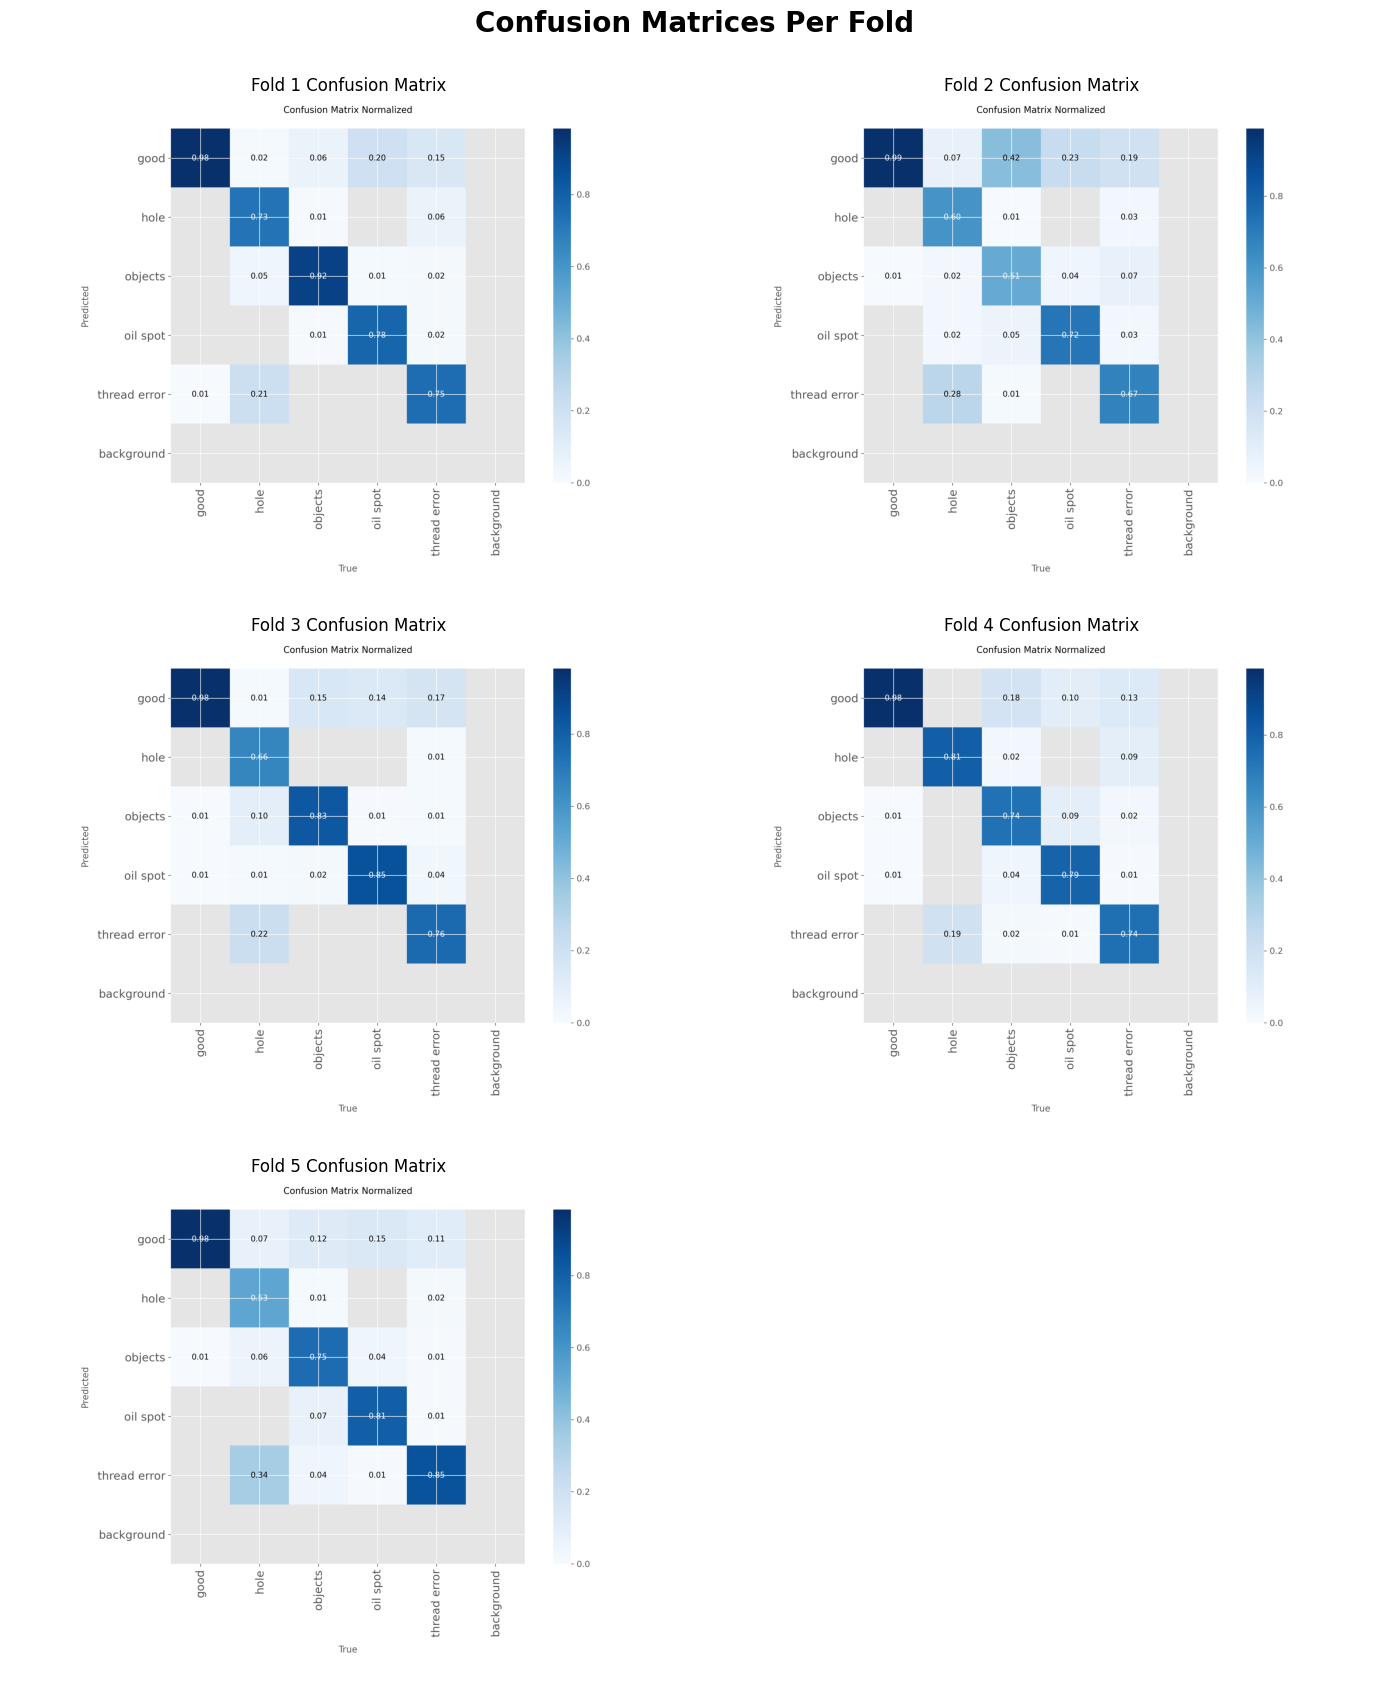

In [28]:
### Displaying Confusion Matrices for Each Fold

if confusion_matrix_paths:
    num_plots = len(confusion_matrix_paths)
    rows = int(np.ceil(num_plots / 2)) # Calculate rows for a 2-column layout
    cols = 2 if num_plots > 0 else 1

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 6)) # Adjust figsize
    axes = axes.flatten() # Flatten the array of axes for easy iteration, even if it's 1D

    for i, (cm_path, fold_num) in enumerate(confusion_matrix_paths):
        try:
            cm_img = Image.open(cm_path)
            axes[i].imshow(cm_img)
            axes[i].set_title(f"Fold {fold_num} Confusion Matrix", fontsize=12)
            axes[i].axis('off')
        except Exception as e:
            axes[i].set_title(f"Fold {fold_num} CM (Error)", fontsize=12, color='red')
            axes[i].text(0.5, 0.5, "Image not found or error", ha='center', va='center', color='red', transform=axes[i].transAxes)
            axes[i].axis('off')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    plt.suptitle("Confusion Matrices Per Fold", fontsize=20, weight='bold')
    plt.show()
else:
    print("No confusion matrices were found to display.")

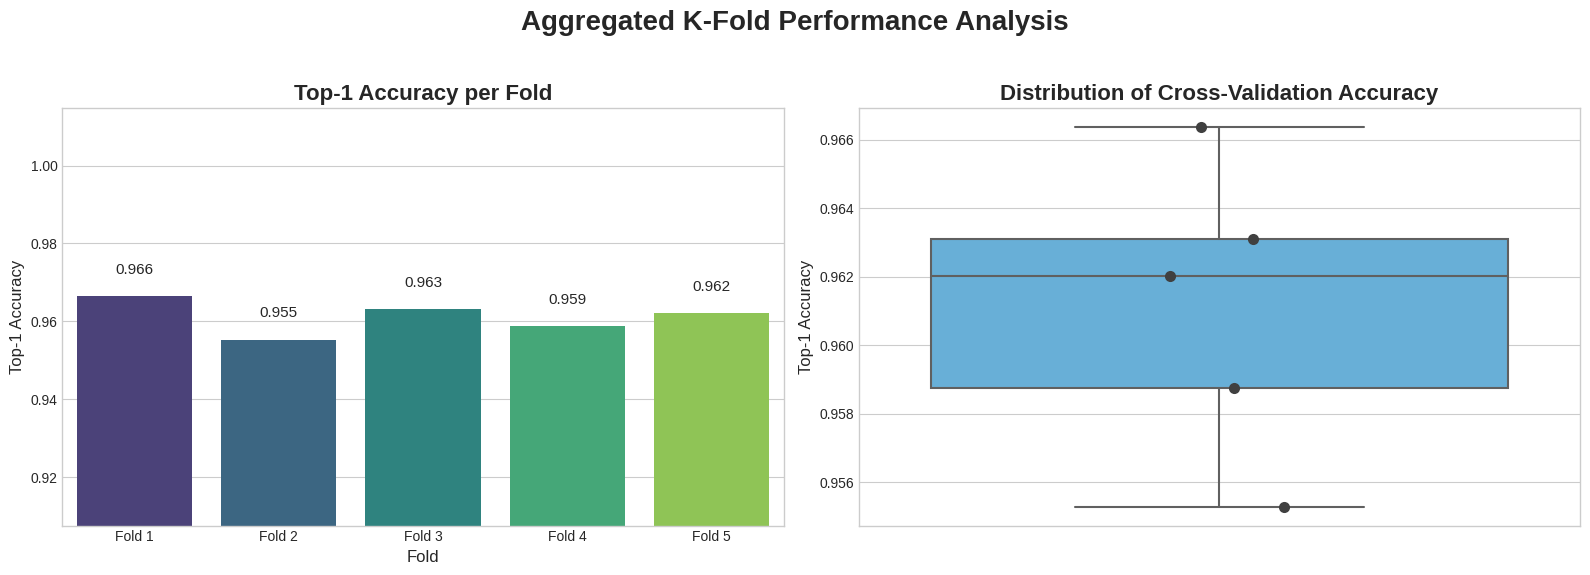

In [29]:
### Aggregate Performance Visualizations

if all_fold_top1_accuracies:
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    fold_labels = [f'Fold {i+1}' for i in range(len(all_fold_top1_accuracies))]

    # 1. Bar Plot: Compare individual fold performance
    sns.barplot(x=fold_labels, y=all_fold_top1_accuracies, ax=ax1, palette='viridis')
    ax1.set_title('Top-1 Accuracy per Fold', fontsize=16, weight='bold')
    ax1.set_xlabel('Fold', fontsize=12)
    ax1.set_ylabel('Top-1 Accuracy', fontsize=12)
    ax1.set_ylim(bottom=max(0, min(all_fold_top1_accuracies) * 0.95)) # Dynamic y-axis to show variations
    for i, v in enumerate(all_fold_top1_accuracies):
        ax1.text(i, v + 0.005, f"{v:.3f}", ha='center', va='bottom', fontsize=11)


    # 2. Box Plot: Show performance distribution
    sns.boxplot(data=all_fold_top1_accuracies, ax=ax2, palette=['#56B4E9'])
    sns.stripplot(data=all_fold_top1_accuracies, ax=ax2, color=".25", size=8, jitter=0.1) # Overlay individual points
    ax2.set_title('Distribution of Cross-Validation Accuracy', fontsize=16, weight='bold')
    ax2.set_ylabel('Top-1 Accuracy', fontsize=12)
    ax2.set_xticklabels(['']) # Hide x-tick label as it's a single box plot

    fig.suptitle('Aggregated K-Fold Performance Analysis', fontsize=20, weight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    plt.show()
else:
    print("No accuracies were recorded to generate aggregated plots.")

In [30]:
if loaded_model and complete_test_image_ids:
    print("\n--- Collecting and Running Batched Inference ---")

    # Run the batched inference
    all_patch_analysis_data = run_batched_patch_inference(
        loaded_model,
        complete_test_image_ids,
        all_image_patches_info,
        mini_batch_size=512
    )
    
    # Run the batched inference
    all_patch_analysis_data = run_batched_patch_inference(
        loaded_model,
        complete_test_image_ids,
        all_image_patches_info,
        mini_batch_size=64
    )
    
elif not complete_test_image_ids:
    print("\nNo complete images available to perform evaluation.")


--- Collecting and Running Batched Inference ---

Collected 2560 patches across 40 images for inference.
  Running inference on mini-batch [0:512] ...
  Running inference on mini-batch [512:1024] ...
  Running inference on mini-batch [1024:1536] ...
  Running inference on mini-batch [1536:2048] ...
  Running inference on mini-batch [2048:2560] ...

--- Batched inference completed on 2560 patches in 1.40 seconds (~0.55 ms per patch) ---

Collected 2560 patches across 40 images for inference.
  Running inference on mini-batch [0:64] ...
  Running inference on mini-batch [64:128] ...
  Running inference on mini-batch [128:192] ...
  Running inference on mini-batch [192:256] ...
  Running inference on mini-batch [256:320] ...
  Running inference on mini-batch [320:384] ...
  Running inference on mini-batch [384:448] ...
  Running inference on mini-batch [448:512] ...
  Running inference on mini-batch [512:576] ...
  Running inference on mini-batch [576:640] ...
  Running inference on mini

## Hyperparameter optimization

In [31]:
set_seed(RANDOM_SEED)

best_tau_1 = tau_1
best_tau_2 = tau_2

if 'loaded_model' in locals() and loaded_model is not None and len(all_patch_analysis_data) > 0:
    print("\n--- Starting tau_1 and tau_2 Hyperparameter Optimization Grid Search ---")

    tau_1_values = HYP_SEARCH_SPACE
    tau_2_values = HYP_SEARCH_SPACE

    optimization_results = []

    best_mean_f1 = -1.0
    best_tau_1 = -1.0
    best_tau_2 = -1.0

    # Build patch data structure by image for fast lookup
    raw_patch_data_by_image = defaultdict(dict)
    for patch_item in all_patch_analysis_data:
        raw_patch_data_by_image[patch_item['image_id']][(patch_item['x'], patch_item['y'])] = {
            'raw_pred_probs': patch_item['raw_pred_probs'],
            'raw_pred_class': patch_item['raw_pred_class'],
            'raw_pred_conf': patch_item['raw_pred_conf'],
            'true_class': patch_item['true_class']
        }

    num_combinations = len(tau_1_values) * len(tau_2_values)
    current_combination_idx = 0

    for current_tau_1 in tau_1_values:
        for current_tau_2 in tau_2_values:
            current_combination_idx += 1

            current_gt_labels_for_eval = []
            current_final_pred_labels_for_eval = []
            current_pred_probs_for_eval = []

            for image_id in sorted(raw_patch_data_by_image.keys()):
                image_patches_raw_data = raw_patch_data_by_image[image_id]

                # --- Step 1: Initial tau_1 thresholding ---
                final_classifications_for_image = {}
                for (x, y), data in image_patches_raw_data.items():
                    pred_class = data['raw_pred_class']
                    pred_conf = data['raw_pred_conf']

                    initial_class = pred_class
                    if initial_class != "good" and pred_conf < current_tau_1:
                        initial_class = "good"

                    final_classifications_for_image[(x, y)] = initial_class

                # --- Step 2: Iterative tau_2 region-growing expansion ---
                expanded = True
                while expanded:
                    expanded = False
                    newly_reclassified = []

                    for (px, py), current_class in final_classifications_for_image.items():
                        if current_class != "good":
                            # look at good neighbors of this defect
                            for (nx, ny) in get_8_connected_neighbors_coords(px, py, max_x=7, max_y=7):
                                if (nx, ny) in final_classifications_for_image and final_classifications_for_image[(nx, ny)] == 'good':
                                    neighbor_data = image_patches_raw_data[(nx, ny)]
                                    neighbor_probs = neighbor_data['raw_pred_probs']

                                    defect_idx = CLASS_NAMES.index(current_class)
                                    prob_for_defect = neighbor_probs[defect_idx]

                                    if prob_for_defect > current_tau_2:
                                        final_classifications_for_image[(nx, ny)] = current_class
                                        newly_reclassified.append((nx, ny))
                                        expanded = True  # at least one new expansion occurred

                # --- Collect evaluation data ---
                for (x, y) in sorted(image_patches_raw_data.keys()):
                    current_gt_labels_for_eval.append(image_patches_raw_data[(x, y)]['true_class'])
                    current_final_pred_labels_for_eval.append(final_classifications_for_image[(x, y)])
                    current_pred_probs_for_eval.append(image_patches_raw_data[(x, y)]['raw_pred_probs'])

            # Evaluate predictions for this tau1/tau2
            metrics = evaluate_patch_predictions(
                current_gt_labels_for_eval,
                current_final_pred_labels_for_eval,
                np.array(current_pred_probs_for_eval),
                CLASS_NAMES,
                verbose=False
            )

            optimization_results.append({
                'tau_1': current_tau_1,
                'tau_2': current_tau_2,
                'accuracy': metrics['accuracy'],
                'mean_precision': metrics['mean_precision'],
                'mean_recall': metrics['mean_recall'],
                'mean_f1': metrics['mean_f1'],
                'roc_auc': metrics['roc_auc']
            })

            if metrics['mean_f1'] > best_mean_f1:
                best_mean_f1 = metrics['mean_f1']
                best_tau_1 = current_tau_1
                best_tau_2 = current_tau_2

    print("\n--- Optimization Complete ---")
    print(f"Optimal (tau_1, tau_2) found (based on Mean F1-score): "
          f"({best_tau_1:.2f}, {best_tau_2:.2f}) with Mean F1-score: {best_mean_f1}")

Random seed set as 42

--- Starting tau_1 and tau_2 Hyperparameter Optimization Grid Search ---

--- Optimization Complete ---
Optimal (tau_1, tau_2) found (based on Mean F1-score): (0.95, 0.09) with Mean F1-score: 0.8398665926688278


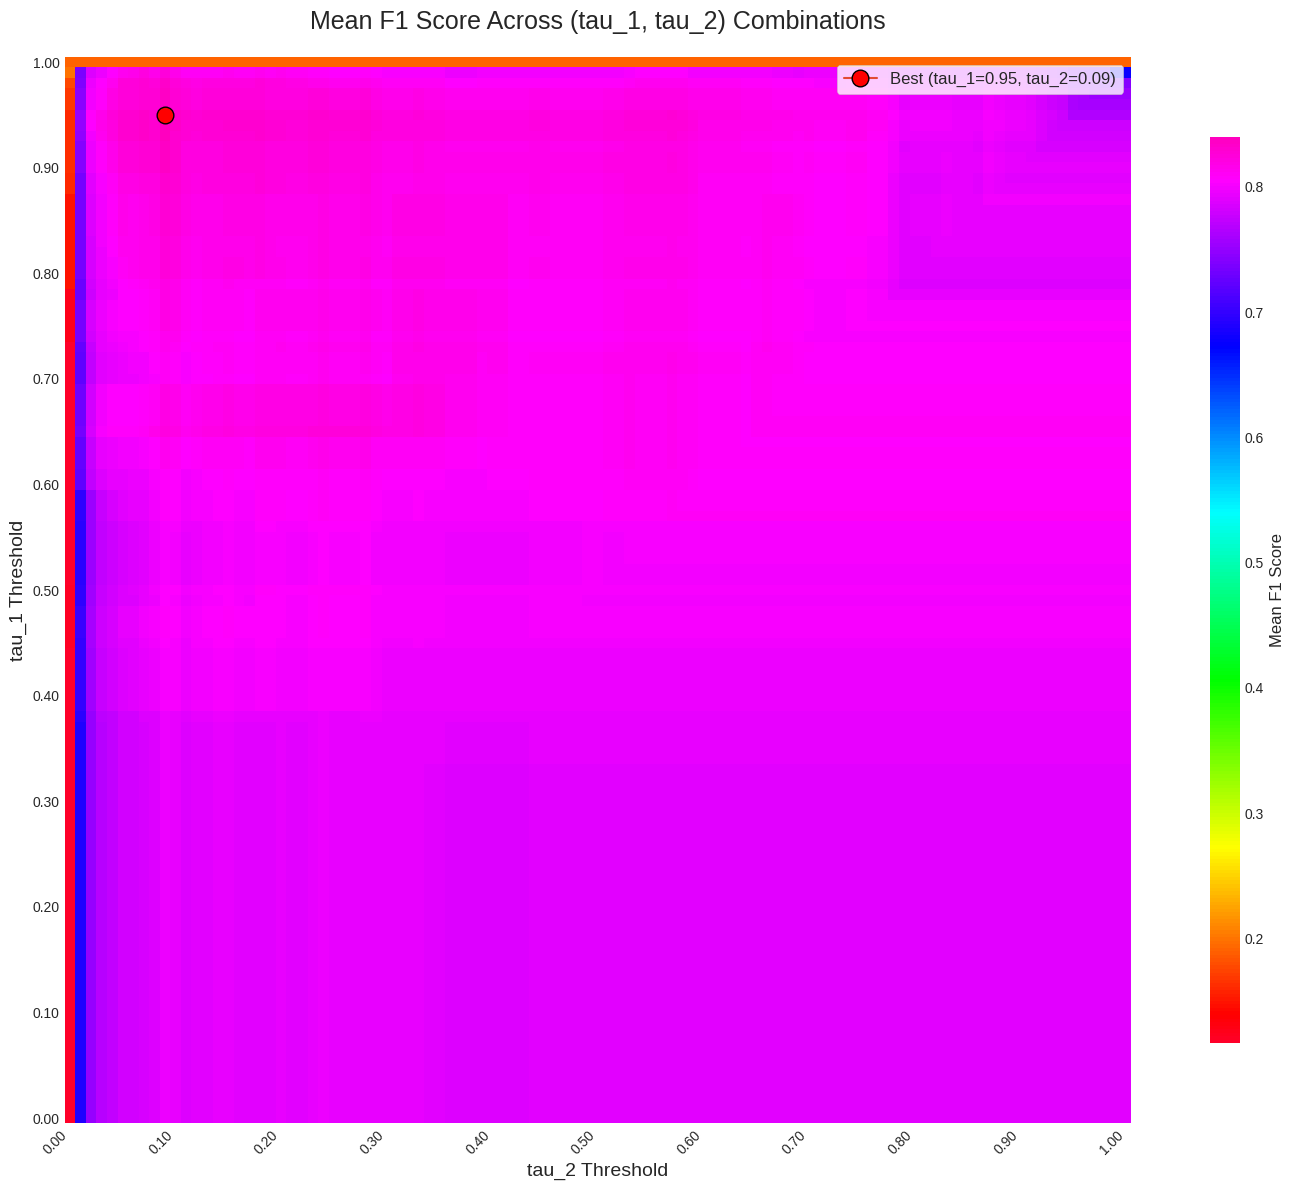

In [32]:
# --- Visualize tau_1 vs. tau_2 vs. Mean F1 (2D Heatmap) ---
plt.figure(figsize=(16, 12))

# Prepare the grid
mean_f1_grid = np.array([res['mean_f1'] for res in optimization_results]).reshape(
    len(tau_1_values), len(tau_2_values)
)

# --- Improved Axis Readability ---
# Determine an interval for displaying labels (e.g., every 0.1 units)
# This depends on your 'tau_x_values' increment. If 0.01, then 0.10 means every 10th index.
# Calculate the step size in terms of array indices
# Assuming uniform increment for tau_1_values and tau_2_values
try:
    # Safely get the increment from the array
    tau_increment = tau_1_values[1] - tau_1_values[0]
except IndexError: # Handle case of too few values to calculate increment
    tau_increment = 0.1 # Default if array is too small for calculation

label_display_interval = 0.10 # Display a label for every 0.1 unit (e.g., 0.00, 0.10, 0.20...)
if tau_increment > 0: # Avoid division by zero
    step_indices = int(label_display_interval / tau_increment)
else: # Fallback for edge cases where increment might be 0 or array is very small
    step_indices = 10 # Default to every 10th label if increment is not positive

# Generate tick locations (indices) and labels for X-axis (tau_2)
x_tick_locations = np.arange(0, len(tau_2_values), step_indices)
x_tick_labels = [f"{tau_2_values[int(loc)]:.2f}" for loc in x_tick_locations]

# Generate tick locations (indices) and labels for Y-axis (tau_1)
y_tick_locations = np.arange(0, len(tau_1_values), step_indices)
y_tick_labels = [f"{tau_1_values[int(loc)]:.2f}" for loc in y_tick_locations]


# Create heatmap
ax = sns.heatmap(
    mean_f1_grid,
    xticklabels=False, # Disable default seaborn xticklabels to use custom ones
    yticklabels=False,
    annot=False,
    fmt=".2f",
    cmap="gist_rainbow",
    square=True,
    cbar_kws={
        'label': 'Mean F1 Score',
        'shrink': 0.85,
        'aspect': 30,
    }
)

plt.title('Mean F1 Score Across (tau_1, tau_2) Combinations', fontsize=18, pad=20)
plt.xlabel('tau_2 Threshold', fontsize=14)
plt.ylabel('tau_1 Threshold', fontsize=14)

# Apply custom tick labels to the axes
# Adding +0.5 to center the tick labels on the cells of the heatmap
ax.set_xticks(x_tick_locations + 0.5)
ax.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=10) # ha='right' for rotated labels

ax.set_yticks(y_tick_locations + 0.5)
ax.set_yticklabels(y_tick_labels, rotation=0, fontsize=10)


plt.gca().invert_yaxis() # Invert y-axis to have 0.00 at the bottom

# Highlight best tau combination with a red marker on the heatmap
best_tau1_idx = np.argmin(np.abs(tau_1_values - best_tau_1))
best_tau2_idx = np.argmin(np.abs(tau_2_values - best_tau_2))

ax.plot(
    best_tau2_idx + 0.5, best_tau1_idx + 0.5,  # +0.5 centers the marker on the cell
    marker='o', markersize=12, markeredgecolor='black', markerfacecolor='red',
    label=f'Best (tau_1={best_tau_1:.2f}, tau_2={best_tau_2:.2f})',
    zorder=5 # Ensure marker is on top
)

plt.legend(loc='upper right', fontsize=12, frameon=True)

plt.tight_layout()
plt.show()

## Raw vs Two-stage refinement metrics

Random seed set as 42

--- Evaluation on Raw Predictions (no thresholds) ---

--- Evaluating 2560 Patch Predictions (Raw) ---

Confusion matrix (rows: Ground Truth, columns: Predicted):
              good         hole         objects      oil spot     thread error 
good         : 2295         4            12           12           11           
hole         : 1            27           1            0            11           
objects      : 11           0            45           0            0            
oil spot     : 28           1            2            60           0            
thread error : 4            1            0            0            34           

Overall patch-level accuracy: 0.961

Class-specific patch-level metrics:
Class           Prec    Rec     F1
good           0.981  0.983  0.982
hole           0.818  0.675  0.740
objects        0.750  0.804  0.776
oil spot       0.833  0.659  0.736
thread error   0.607  0.872  0.716
all classes    0.798  0.799  0.790


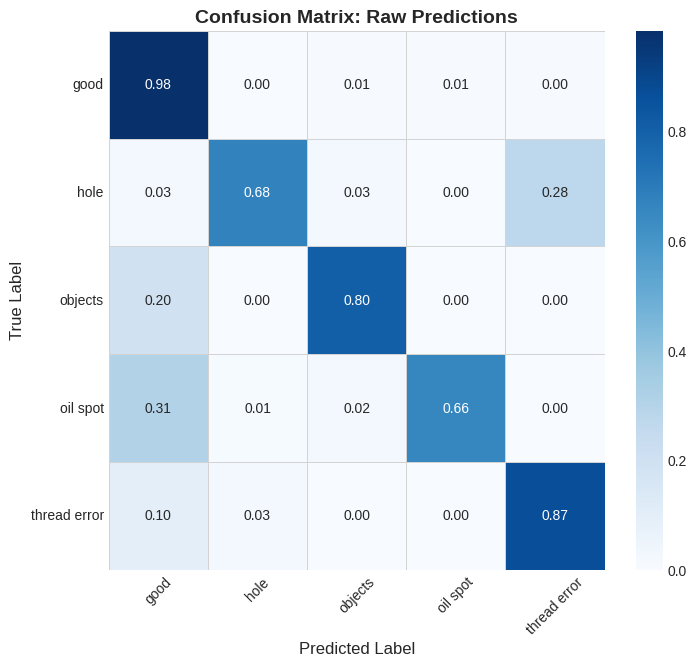


--- Evaluation with tau_1 (0.95) + tau_2 (0.09) logic applied ---

--- Evaluating 2560 Patch Predictions (Flood fill) ---

Confusion matrix (rows: Ground Truth, columns: Predicted):
              good         hole         objects      oil spot     thread error 
good         : 2301         4            11           12           6            
hole         : 14           21           2            0            3            
objects      : 8            0            48           0            0            
oil spot     : 19           0            0            72           0            
thread error : 2            0            0            0            37           

Overall patch-level accuracy: 0.968

Class-specific patch-level metrics:
Class           Prec    Rec     F1
good           0.982  0.986  0.984
hole           0.840  0.525  0.646
objects        0.787  0.857  0.821
oil spot       0.857  0.791  0.823
thread error   0.804  0.949  0.871
all classes    0.854  0.822  0.829


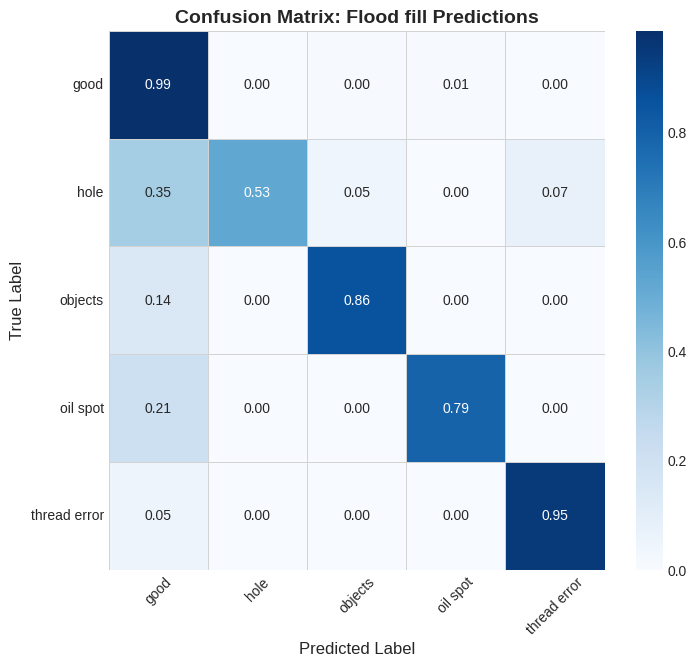


--- Plotting F1-Score Comparison ---


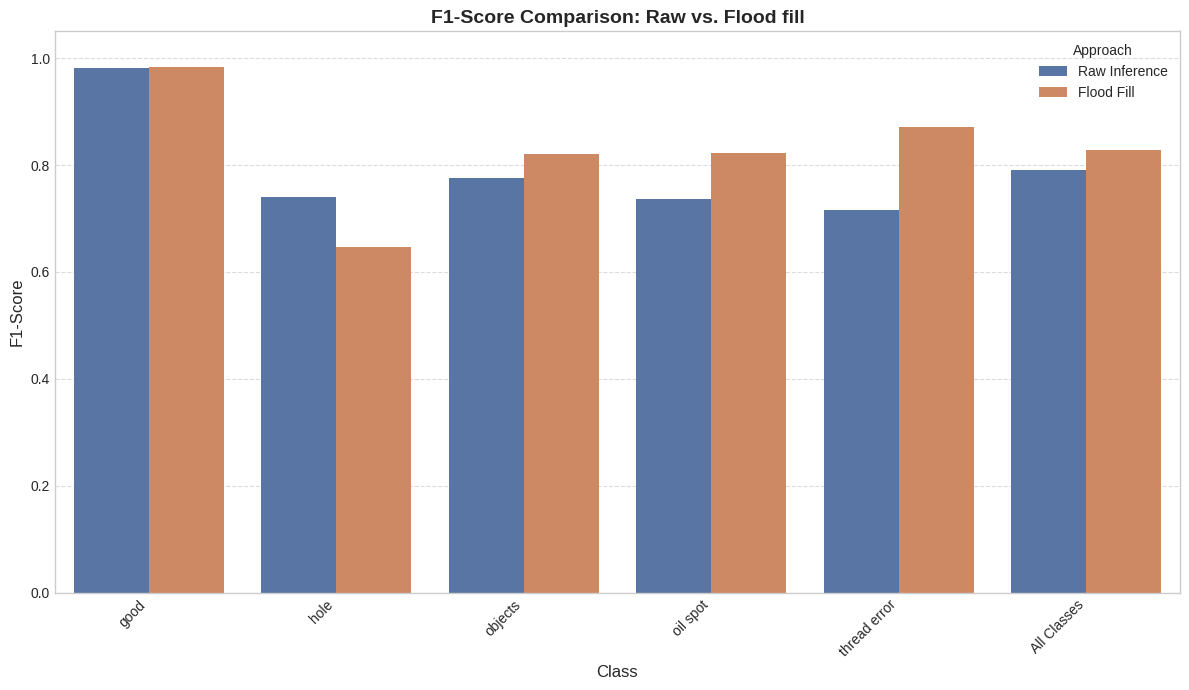

In [33]:
set_seed(RANDOM_SEED)

try:
    # === RAW PREDICTIONS EVALUATION ===
    print("\n--- Evaluation on Raw Predictions (no thresholds) ---")
    gt_labels_raw = [d['true_class'] for d in all_patch_analysis_data]
    pred_labels_raw = [d['raw_pred_class'] for d in all_patch_analysis_data]
    pred_probs_raw = np.array([d['raw_pred_probs'] for d in all_patch_analysis_data])

    raw_metrics = evaluate_patch_predictions(
        gt_labels_raw,
        pred_labels_raw,
        pred_probs_raw,
        CLASS_NAMES,
        verbose=True,
        plot_cm=True,
        approach_name="Raw"
    )

    # === TAU_1 + TAU_2 LOGIC EVALUATION ===
    print(f"\n--- Evaluation with tau_1 ({best_tau_1:.2f}) + tau_2 ({best_tau_2:.2f}) logic applied ---")
    final_labels_tau12 = []
    for d in all_patch_analysis_data:
        pred_label = d['raw_pred_class']
        if pred_label != "good" and d['raw_pred_conf'] < best_tau_1:
            pred_label = "good"
        d['intermediate_label'] = pred_label  # store intermediate for tau_2 phase
        final_labels_tau12.append(pred_label)

    # Apply tau_2 region growing
    coords_to_idx = {(d['image_id'], d['x'], d['y']): idx for idx, d in enumerate(all_patch_analysis_data)}
    to_expand = [(d['image_id'], d['x'], d['y']) for d, label in zip(all_patch_analysis_data, final_labels_tau12) if label != "good"]
    visited = set()

    while to_expand:
        image_id, x, y = to_expand.pop(0)
        idx = coords_to_idx[(image_id, x, y)]
        defect_class = final_labels_tau12[idx]
        neighbors = get_8_connected_neighbors_coords(x, y, max_x=7, max_y=7)
        for nx, ny in neighbors:
            coord = (image_id, nx, ny)
            if coord in coords_to_idx and coord not in visited:
                nidx = coords_to_idx[coord]
                if final_labels_tau12[nidx] == "good":
                    prob_array = all_patch_analysis_data[nidx]['raw_pred_probs']
                    defect_idx = CLASS_NAMES.index(defect_class)
                    if prob_array[defect_idx] > best_tau_2:
                        final_labels_tau12[nidx] = defect_class
                        to_expand.append(coord)
                visited.add(coord)

    tau12_metrics = evaluate_patch_predictions(
        gt_labels_raw,
        final_labels_tau12,
        pred_probs_raw,
        CLASS_NAMES,
        verbose=True,
        plot_cm=True,
        approach_name="Flood fill"
    )

except Exception as e:
    print(f"An error occurred during model loading or evaluation: {e}")

# 3. Bar comparison for F1-score for both approaches
if raw_metrics and tau12_metrics:
    print("\n--- Plotting F1-Score Comparison ---")
    plot_f1_comparison(
        f1_raw=raw_metrics['f1'],
        f1_tau12=tau12_metrics['f1'],
        class_names=CLASS_NAMES,
        title="F1-Score Comparison: Raw vs. Flood fill"
    )
else:
    print("Cannot plot F1-score comparison: Metrics not available for both approaches.")

## Speed

Random seed set as 42

Using your previously loaded model for multi-image speed testing.

--- Running Speed Test with 10 Images ---

--- Starting Speed Test (5 runs, simulating 10 images each) ---

Running test iteration 1/5...
Phase 1 (Preprocessing) completed for 10 images.

Collected 640 patches across 10 images for inference.
  Running inference on mini-batch [0:512] ...
  Running inference on mini-batch [512:640] ...

--- Batched inference completed on 640 patches in 0.33 seconds (~0.51 ms per patch) ---
Phase 2 (Batched Inference) completed for 640 patches.
Phase 3 (Post-processing) completed for 10 images.

Running test iteration 2/5...
Phase 1 (Preprocessing) completed for 10 images.

Collected 640 patches across 10 images for inference.
  Running inference on mini-batch [0:512] ...
  Running inference on mini-batch [512:640] ...

--- Batched inference completed on 640 patches in 0.31 seconds (~0.48 ms per patch) ---
Phase 2 (Batched Inference) completed for 640 patches.
Phase 

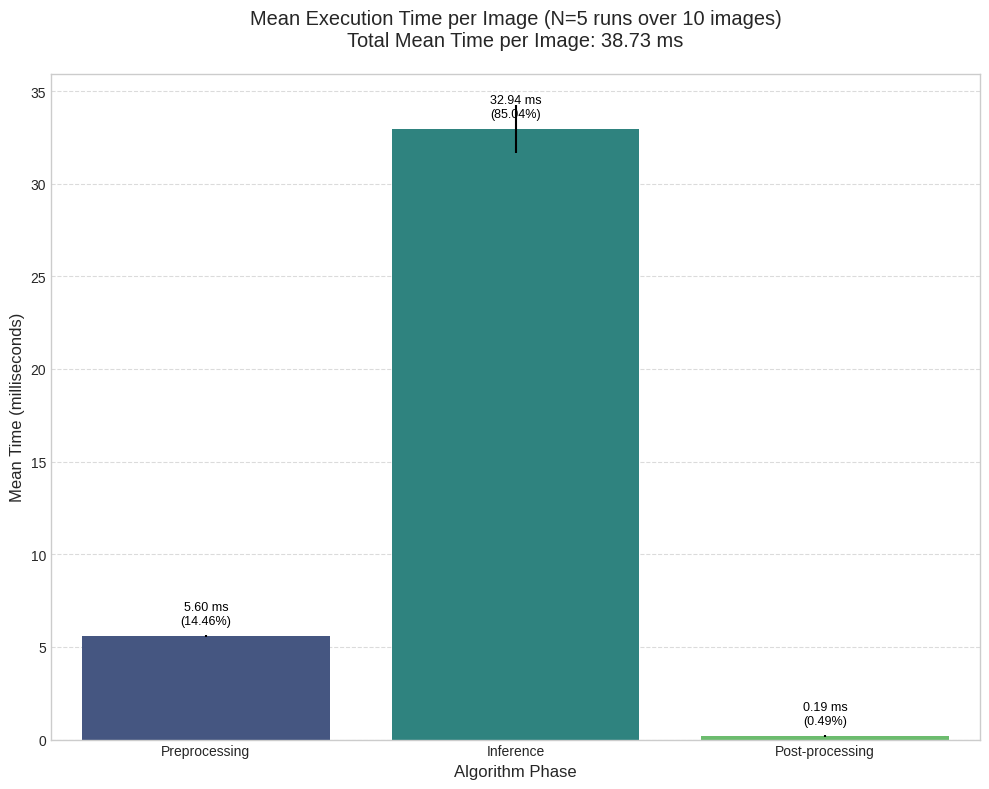

In [34]:
set_seed(RANDOM_SEED)

def run_speed_test(
    model_to_use,
    image_url, patch_size, final_image_size, tau_1, tau_2,
    num_test_runs=1,
    num_simulated_images=1, # New optional flag
    inference_mini_batch_size=512 # New adjustable batch size for inference
):
    # Use model's names if available, else fallback to global CLASS_NAMES
    current_class_names = model_to_use.names if hasattr(model_to_use, 'names') else CLASS_NAMES

    preprocessing_times = []
    inference_times = []
    postprocessing_times = []
    combined_times = []
    
    # Pre-fetch the base image once
    try:
        response = requests.get(image_url)
        response.raise_for_status()
        base_img = Image.open(BytesIO(response.content)).convert("RGB")
    except requests.exceptions.RequestException as e:
        print(f"Error loading base image from URL: {e}.")
        return
    except Exception as e:
        print(f"Error opening base image: {e}.")
        return

    print(f"\n--- Starting Speed Test ({num_test_runs} runs, simulating {num_simulated_images} images each) ---")

    # Pre-check: Ensure the model is actually loaded before starting tests
    if model_to_use is None:
        print("Error: `model_to_use` is None. Please ensure a model is loaded before calling `run_speed_test`.")
        return
    
    for run_idx in range(num_test_runs):
        print(f"\nRunning test iteration {run_idx + 1}/{num_test_runs}...")
        
        overall_start_time = time.time()
        
        # --- Phase 1: Preprocessing (for multiple simulated images) ---
        phase1_start_time = time.time()
        
        all_image_patches_info = defaultdict(list) # Stores (patch_img, x, y, true_class) for each image_id
        all_image_ids = []

        for img_sim_idx in range(num_simulated_images):
            image_id = f"sim_img_{img_sim_idx}" # Unique ID for each simulated image
            all_image_ids.append(image_id)

            original_width, original_height = base_img.size
            
            if final_image_size:
                 img_resized = base_img.resize((final_image_size, final_image_size), Image.LANCZOS)
            else:
                 target_width = (original_width // patch_size) * patch_size
                 target_height = (original_height // patch_size) * patch_size
                 img_resized = base_img.resize((target_width, target_height), Image.LANCZOS)

            rows = img_resized.height // patch_size
            cols = img_resized.width // patch_size
            
            for y_idx in range(rows):
                for x_idx in range(cols):
                    left = x_idx * patch_size
                    top = y_idx * patch_size
                    right = left + patch_size
                    bottom = top + patch_size
                    patch_img = img_resized.crop((left, top, right, bottom))
                    
                    mock_true_class = random.choice(current_class_names) 
                    # Store the actual PIL Image object and its metadata
                    all_image_patches_info[image_id].append((patch_img, x_idx, y_idx, mock_true_class))

        phase1_end_time = time.time()
        preprocessing_times.append(phase1_end_time - phase1_start_time)
        print(f"Phase 1 (Preprocessing) completed for {num_simulated_images} images.")

        # --- Phase 2: Inference (BATCHED across all patches from all images) ---
        phase2_start_time = time.time()
        
        # Call your pre-defined batched inference function
        all_patch_analysis_data = run_batched_patch_inference(
            model_to_use, 
            all_image_ids, 
            all_image_patches_info, 
            inference_mini_batch_size 
        )

        phase2_end_time = time.time()
        inference_times.append(phase2_end_time - phase2_start_time)
        print(f"Phase 2 (Batched Inference) completed for {len(all_patch_analysis_data)} patches.")

        # --- Phase 3: Post-processing (Flood Fill Detection) for each image individually ---
        phase3_start_time = time.time()
        
        # Reorganize all_patch_analysis_data by image_id for individual post-processing
        results_by_image = defaultdict(list)
        for patch_result in all_patch_analysis_data:
            results_by_image[patch_result['image_id']].append(patch_result)

        final_post_processed_results = {}
        for image_id, image_patch_results in results_by_image.items():
            # Create a patch_data map specific to this image for post-processing
            patch_data_for_image = {}
            for res in image_patch_results:
                patch_data_for_image[(res['x'], res['y'])] = {
                    'raw_pred_class': res['raw_pred_class'],
                    'raw_pred_conf': res['raw_pred_conf'],
                    'raw_pred_probs': res['raw_pred_probs']
                }

            final_tau12 = {}
            for (x, y), data in patch_data_for_image.items():
                pred_class = data['raw_pred_class']
                pred_conf = data['raw_pred_conf']
                if pred_class != "good" and pred_conf < tau_1:
                    final_tau12[(x, y)] = 'good'
                else:
                    final_tau12[(x, y)] = pred_class

            queue = [(x, y, c) for (x, y), c in final_tau12.items() if c != 'good']
            visited = set(queue)

            max_patch_x = (final_image_size // patch_size) - 1
            max_patch_y = (final_image_size // patch_size) - 1

            while queue:
                px, py, primary_defect_class = queue.pop(0)
                for nx, ny in get_8_connected_neighbors_coords(px, py, max_patch_x, max_patch_y):
                    if (nx, ny) not in patch_data_for_image or (nx, ny) in visited:
                        continue
                    
                    if final_tau12.get((nx, ny)) == 'good':
                        if primary_defect_class in current_class_names: # Use current_class_names for robustness
                            defect_idx = current_class_names.index(primary_defect_class)
                            neighbor_probs = patch_data_for_image[(nx, ny)]['raw_pred_probs']
                            
                            if defect_idx < len(neighbor_probs):
                                prob_for_adj_defect = neighbor_probs[defect_idx]
                                if prob_for_adj_defect > tau_2:
                                    final_tau12[(nx, ny)] = primary_defect_class
                                    queue.append((nx, ny, primary_defect_class))
                                    visited.add((nx, ny))
            final_post_processed_results[image_id] = final_tau12 # Store results for this image
        
        phase3_end_time = time.time()
        postprocessing_times.append(phase3_end_time - phase3_start_time)
        print(f"Phase 3 (Post-processing) completed for {num_simulated_images} images.")
        
        overall_end_time = time.time()
        combined_times.append(overall_end_time - overall_start_time)

    # --- Results Summary ---
    print("\n" + "="*70)
    print("--- Algorithm Speed Test Results (Multi-Image Batched Inference) ---")
    print("="*70)

    if num_test_runs > 0 and combined_times:
        print(f"Number of test runs (full pipeline): {num_test_runs}")
        print(f"Simulated images per run: {num_simulated_images}")
        print(f"Inference mini-batch size: {inference_mini_batch_size}")
        
        mean_p1 = np.mean(preprocessing_times)
        std_p1 = np.std(preprocessing_times)
        print(f"\nPhase 1 (Preprocessing - Resize & Patch {num_simulated_images} images):")
        print(f"  Mean time: {mean_p1:.4f} seconds (Std Dev: {std_p1:.4f} s)")

        mean_p2 = np.mean(inference_times)
        std_p2 = np.std(inference_times)
        print(f"\nPhase 2 (Inference - BATCHED on ALL patches):")
        print(f"  Mean time: {mean_p2:.4f} seconds (Std Dev: {std_p2:.4f} s)")

        mean_p3 = np.mean(postprocessing_times)
        std_p3 = np.std(postprocessing_times)
        print(f"\nPhase 3 (Post-processing - Flood Fill per image):")
        print(f"  Mean time: {mean_p3:.4f} seconds (Std Dev: {std_p3:.4f} s)")

        mean_combined = np.mean(combined_times)
        std_combined = np.std(combined_times)
        print(f"\nOverall Combined Time (Phases 1+2+3 for {num_simulated_images} images):")
        print(f"  Mean time: {mean_combined:.4f} seconds (Std Dev: {std_combined:.4f} s)")
        
        print("\nTime Breakdown by Phase:")
        print(f"  Preprocessing: {(mean_p1 / mean_combined * 100):.2f}%")
        print(f"  Inference (BATCHED): {(mean_p2 / mean_combined * 100):.2f}%")
        print(f"  Post-processing: {(mean_p3 / mean_combined * 100):.2f}%")

        # --- Plotting Visualizations ---
        print("\n--- Generating Performance Plots (Mean Time Per Image) ---")
        
        # Calculate mean times *per image* (in seconds first)
        mean_p1_per_image = mean_p1 / num_simulated_images
        mean_p2_per_image = mean_p2 / num_simulated_images
        mean_p3_per_image = mean_p3 / num_simulated_images
        mean_combined_per_image = mean_combined / num_simulated_images
        
        # Convert these per-image mean times to milliseconds
        mean_p1_per_image_ms = mean_p1_per_image * 1000
        mean_p2_per_image_ms = mean_p2_per_image * 1000
        mean_p3_per_image_ms = mean_p3_per_image * 1000
        mean_combined_per_image_ms = mean_combined_per_image * 1000
        
        # Standard deviations per image (assuming std also scales linearly with the number of images)
        std_p1_per_image_ms = (std_p1 / num_simulated_images) * 1000
        std_p2_per_image_ms = (std_p2 / num_simulated_images) * 1000
        std_p3_per_image_ms = (std_p3 / num_simulated_images) * 1000
        
        phases = ['Preprocessing', 'Inference', 'Post-processing']
        mean_times_ms = [mean_p1_per_image_ms, mean_p2_per_image_ms, mean_p3_per_image_ms]
        std_times_ms = [std_p1_per_image_ms, std_p2_per_image_ms, std_p3_per_image_ms]
        
        plt.figure(figsize=(10, 8))
        barplot = sns.barplot(x=phases, y=mean_times_ms, yerr=std_times_ms, palette='viridis', capsize=0.1)
        
        plt.title(
            f'Mean Execution Time per Image (N={num_test_runs} runs over {num_simulated_images} images)\n'
            f'Total Mean Time per Image: {mean_combined_per_image_ms:.2f} ms',
            pad=20
        )
        plt.ylabel('Mean Time (milliseconds)')
        plt.xlabel('Algorithm Phase')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Add values and percentages above each bar
        for i, bar in enumerate(barplot.patches):
            # Percentages remain the same as the ratios don't change when scaling all values equally.
            percentage = (mean_times_ms[i] / mean_combined_per_image_ms * 100) if mean_combined_per_image_ms > 0 else 0
        
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5,
                     f'{mean_times_ms[i]:.2f} ms\n({percentage:.2f}%)',
                     ha='center', va='bottom', fontsize=9, color='black')
        
        plt.tight_layout()
        plt.show()

    else:
        print("No test runs were completed or data collected, skipping plot generation.")

if loaded_model is not None:
    print("\nUsing your previously loaded model for multi-image speed testing.")

    n_test = 10
    print(f"\n--- Running Speed Test with {n_test} Images ---")
    run_speed_test(
        model_to_use=loaded_model,
        image_url=SAMPLE_IMAGE_URL,
        patch_size=PATCH_SIZE,
        final_image_size=FINAL_IMAGE_SIZE,
        tau_1=best_tau_1,
        tau_2=best_tau_2,
        num_test_runs=5,
        num_simulated_images=n_test,
        inference_mini_batch_size=512
    )

    # print("\n" + "="*70)
    # print("\n--- Running Speed Test with Single Image (for comparison) ---")
    # run_speed_test(
    #     model_to_use=loaded_model,
    #     image_url=SAMPLE_IMAGE_URL,
    #     patch_size=PATCH_SIZE,
    #     final_image_size=FINAL_IMAGE_SIZE,
    #     tau_1=best_tau_1,
    #     tau_2=best_tau_2,
    #     num_test_runs=5,
    #     num_simulated_images=1
    # )

else:
    print("\n'loaded_model' not found or is None. Please ensure your model is loaded in a preceding cell.")
    print("Cannot proceed with speed test without a loaded model.")

## Qualitative results

Random seed set as 42

--- Visualizing Predictions for a Few Random Test Images ---

--- Reconstructing Image ID: '217' with tau_1=0.95, tau_2=0.09 ---


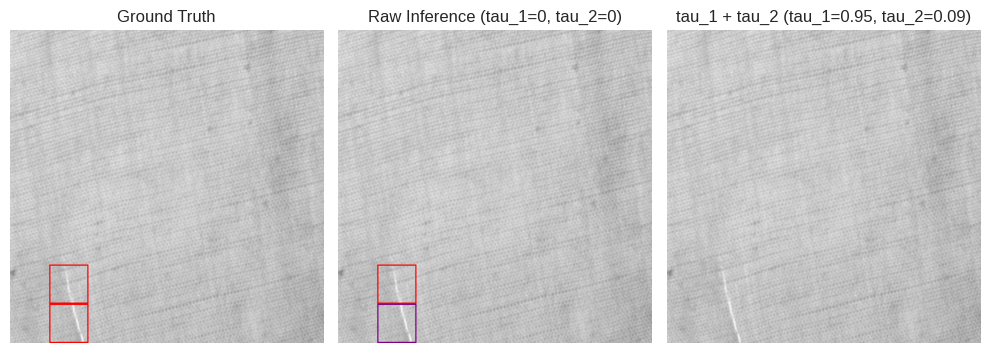


--- Reconstructing Image ID: '367' with tau_1=0.95, tau_2=0.09 ---


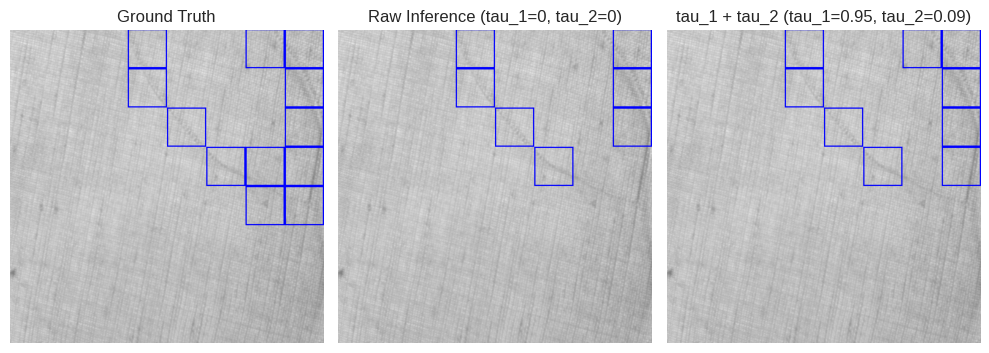


--- Reconstructing Image ID: '169' with tau_1=0.95, tau_2=0.09 ---


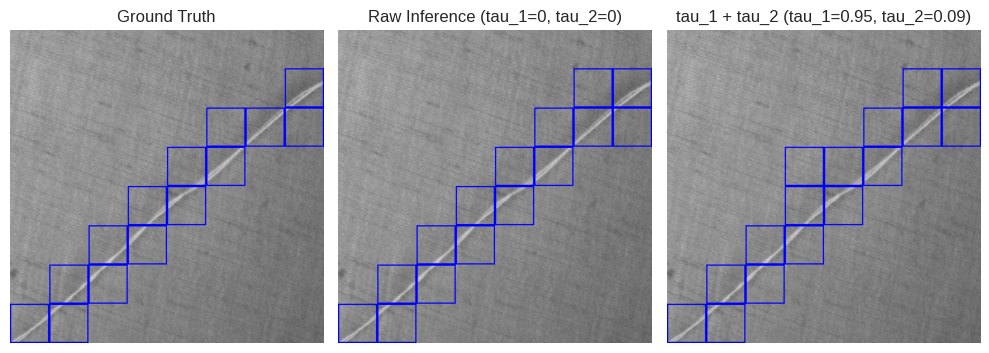


--- Reconstructing Image ID: '068' with tau_1=0.95, tau_2=0.09 ---


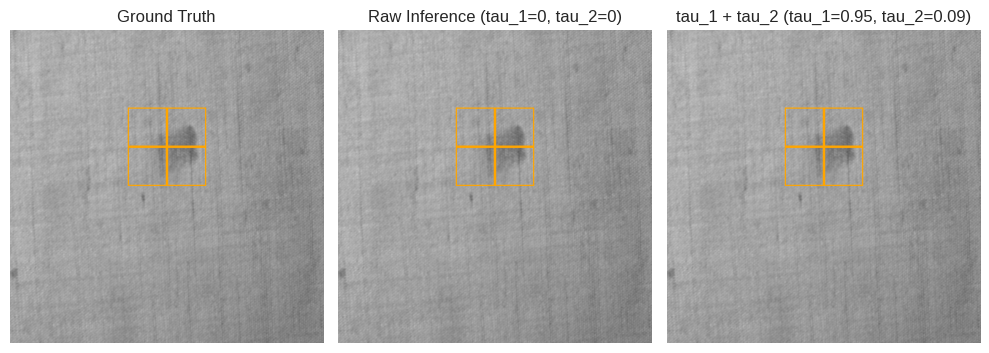


--- Reconstructing Image ID: '246' with tau_1=0.95, tau_2=0.09 ---


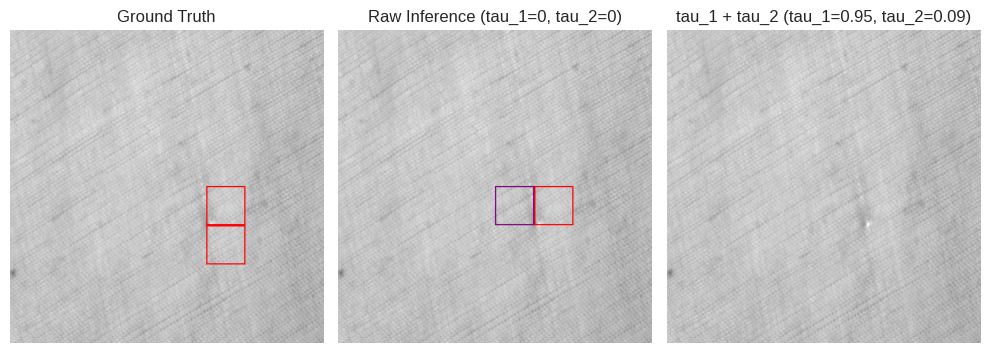


--- All Analysis Complete ---


In [35]:
set_seed(RANDOM_SEED)

if loaded_model and complete_test_image_ids:
    print("\n--- Visualizing Predictions for a Few Random Test Images ---")

    num_samples_to_visualize = min(5, len(complete_test_image_ids))
    
    if num_samples_to_visualize > 0:
        random_image_ids_to_visualize = random.sample(complete_test_image_ids, num_samples_to_visualize)
        
        for img_id in random_image_ids_to_visualize:
            reconstruct_image_with_predictions(
                loaded_model, img_id, all_image_patches_info, CLASS_COLORS, PATCH_SIZE, FINAL_IMAGE_SIZE, best_tau_1, best_tau_2, False
            )
    else:
        print("Not enough complete images in the test set for visual reconstruction.")
else:
    print("\nSkipping visual inspection: Model not loaded or no complete test images available.")

print("\n--- All Analysis Complete ---")